In [ ]:
# =========================================================
# Heart Disease  Analysis Script
# Separate Training (Cleveland) & Testing (Hungarian)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import VotingClassifier

sns.set_style("whitegrid")

# Toggle plotting display; when False, plots are saved to `plots/` instead of shown
DISPLAY_PLOTS = False
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Suppress sklearn FutureWarnings/UserWarnings about deprecated penalty usage
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [ ]:
# =========================================================
# 1. Load Training & Testing Datasets
# =========================================================

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
test_urls = {
    'Hungarian': "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    'Switzerland': "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    'VA': "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
}

column_names = [
    'age','sex','cp','trestbps','chol','fbs','restecg','thalach',
    'exang','oldpeak','slope','ca','thal','diagnosis'
]

target_col = 'diagnosis'

df_train = pd.read_csv(train_url, header=None, names=column_names, na_values='?')

df_tests = {}
for name, url in test_urls.items():
    try:
        df = pd.read_csv(url, header=None, names=column_names, na_values='?')
        df_tests[name] = df
    except Exception as e:
        print(f"Warning: could not load {name} from URL ({e}). It will be skipped.")

if len(df_tests) == 0:
    dp_train = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"
    print("Warning: UCI test files unavailable; falling back to dataprofessor Cleveland and splitting for test.")
    df_train = pd.read_csv(dp_train)
    from sklearn.model_selection import train_test_split
    if 'diagnosis' in df_train.columns:
        df_tr, df_te = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['diagnosis'])
    else:
        df_tr, df_te = train_test_split(df_train, test_size=0.2, random_state=42)
    df_train = df_tr
    df_tests = {'SplitTest': df_te}

df_train.columns = df_train.columns.str.strip()
for k in list(df_tests.keys()):
    df_tests[k].columns = df_tests[k].columns.str.strip()

print("Training dataset shape:", df_train.shape)
for name, df in df_tests.items():
    print(f"Testing dataset shape ({name}):", df.shape)

Training dataset shape: (303, 14)
Testing dataset shape (Hungarian): (294, 14)
Testing dataset shape (Switzerland): (123, 14)
Testing dataset shape (VA): (200, 14)


In [ ]:
# =========================================================
# 2. Preprocessing Function
# =========================================================

def preprocess(df):
    df = df.copy()
    df.replace('?', np.nan, inplace=True)
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.fillna(df.mean(numeric_only=True))
    categorical_cols = ['cp', 'restecg', 'slope', 'thal']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0]).astype(int)
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    df['smoking'] = np.random.randint(0, 2, size=len(df))
    return df

df_train_encoded = preprocess(df_train)
df_tests_encoded = {}
for name, df in df_tests.items():
    df_enc = preprocess(df)
    df_enc = df_enc.reindex(columns=df_train_encoded.columns, fill_value=0)
    df_tests_encoded[name] = df_enc

print("\nFirst 5 rows of training (encoded):")
print(df_train_encoded.head())
for name, df_enc in df_tests_encoded.items():
    print(f"\nFirst 5 rows of test dataset: {name} (encoded)")
    print(df_enc.head())


First 5 rows of training (encoded):
    age  sex  trestbps   chol  fbs  thalach  exang  oldpeak   ca  diagnosis  \
0  63.0  1.0     145.0  233.0  1.0    150.0    0.0      2.3  0.0          0   
1  67.0  1.0     160.0  286.0  0.0    108.0    1.0      1.5  3.0          2   
2  67.0  1.0     120.0  229.0  0.0    129.0    1.0      2.6  2.0          1   
3  37.0  1.0     130.0  250.0  0.0    187.0    0.0      3.5  0.0          0   
4  41.0  0.0     130.0  204.0  0.0    172.0    0.0      1.4  0.0          0   

   ...  cp_3  cp_4  restecg_1  restecg_2  slope_2  slope_3  thal_4  thal_6  \
0  ...     0     0          0          1        0        1       0       1   
1  ...     0     1          0          1        1        0       0       0   
2  ...     0     1          0          1        1        0       0       0   
3  ...     1     0          0          0        0        1       0       0   
4  ...     0     0          0          1        0        0       0       0   

   thal_7  smoking 

In [ ]:
import numpy as np

# =========================================================
# 0. Columns where 0 is invalid
# =========================================================
cols_with_fake_zero = ["chol", "trestbps", "thalach", "oldpeak"]

# Replace 0 with NaN in both training and test datasets
for col in cols_with_fake_zero:
    df_train_encoded[col] = df_train_encoded[col].replace(0, np.nan)
    for name, df_enc in df_tests_encoded.items():
        df_enc[col] = df_enc[col].replace(0, np.nan)

# =========================================================
# 3. Dataset Comparison
# =========================================================
train_means = df_train_encoded.drop(columns=[target_col]).mean()

for name, df_enc in df_tests_encoded.items():
    test_means = df_enc.drop(columns=[target_col]).mean()
    mean_diff = (train_means - test_means).abs().sort_values(ascending=False)
    print(f"\n{name} (shape {df_enc.shape}) top 5 diff:")
    print(mean_diff.head(5))

print("\nTraining encoded features (columns) and count:")
print(list(df_train_encoded.columns))
print(f"Total features (training): {len(df_train_encoded.columns)}")

for name, df_enc in df_tests_encoded.items():
    print(f"\n{name} encoded features (columns) and count:")
    print(list(df_enc.columns))
    print(f"Total features ({name}): {len(df_enc.columns)}")



Hungarian (shape (294, 21)) top 5 diff:
thalach     10.477568
age          6.612413
chol         4.155639
trestbps     0.893849
ca           0.672241
dtype: float64

Switzerland (shape (123, 21)) top 5 diff:
thalach     28.049884
trestbps     1.483157
ca           0.927759
age          0.878129
oldpeak      0.551240
dtype: float64

VA (shape (200, 21)) top 5 diff:
thalach     26.811342
chol         9.943249
age          4.911056
trestbps     2.746300
thal_6       0.810594
dtype: float64

Training encoded features (columns) and count:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'diagnosis', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_4', 'thal_6', 'thal_7', 'smoking']
Total features (training): 21

Hungarian encoded features (columns) and count:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'diagnosis', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_4', '

In [ ]:
# =========================================================
# 4. Separate Features & Target
# =========================================================
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*70)
print("STEP 1: BALANCING TRAINING DATA")
print("="*70)

# 🔹 Create balancing pipeline
balancing_pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('under', RandomUnderSampler(random_state=42))
])

# 🔹 Show original distribution
print("Original Training Distribution:")
print(y_train.value_counts())

# 🔹 Apply balancing
X_train_bal, y_train_bal = balancing_pipeline.fit_resample(X_train, y_train)

# Convert back to DataFrame
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_train_bal = pd.Series(y_train_bal, name=y_train.name)

print("\nBalanced Training Distribution:")
print(y_train_bal.value_counts())
print("Balanced Training Shape:", X_train_bal.shape)


print("\n" + "="*70)
print("="*70)

# 🔹 Train model (you can change this model)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_bal, y_train_bal)

print("Model training completed.")


print("\n" + "="*70)
print("="*70)

results = []

for name, X_test in X_tests.items():

    y_test = y_tests[name]

    print(f"\nEvaluating on: {name}")
    print("-"*50)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-Score :", round(f1, 4))
    print("Confusion Matrix:\n", cm)

    results.append([name, acc, prec, rec, f1])


print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame(results, columns=["Dataset", "Accuracy", "Precision", "Recall", "F1"])
print(results_df)



STEP 1: BALANCING TRAINING DATA
Original Training Distribution:
diagnosis
0    164
1    139
Name: count, dtype: int64

Balanced Training Distribution:
diagnosis
0    164
1    164
Name: count, dtype: int64
Balanced Training Shape: (328, 19)

Model training completed.


Evaluating on: Hungarian
--------------------------------------------------
Accuracy : 0.8299
Precision: 0.839
Recall   : 0.8299
F1-Score : 0.8207
Confusion Matrix:
 [[180   8]
 [ 42  64]]

Evaluating on: Switzerland
--------------------------------------------------
Accuracy : 0.8537
Precision: 0.9138
Recall   : 0.8537
F1-Score : 0.8785
Confusion Matrix:
 [[  4   4]
 [ 14 101]]

Evaluating on: VA
--------------------------------------------------
Accuracy : 0.66
Precision: 0.7369
Recall   : 0.66
F1-Score : 0.6806
Confusion Matrix:
 [[34 17]
 [51 98]]

FINAL RESULTS SUMMARY
       Dataset  Accuracy  Precision    Recall        F1
0    Hungarian  0.829932   0.838961  0.829932  0.820741
1  Switzerland  0.853659   0.913795  

In [ ]:
# =========================================================
# 5. Boxplot Before Scaling (Training)
# =========================================================

plt.figure(figsize=(12,6))
X_train.boxplot()
plt.title("Box Plot of Training Features Before Scaling")
plt.xticks(rotation=45)
if DISPLAY_PLOTS:
    plt.show()
else:
    plt.savefig(os.path.join(PLOT_DIR,'box_before_scaling.png'), bbox_inches='tight')
    plt.close()


In [ ]:
# =========================================================
# 6. Standardization (Outlier Features)
# =========================================================

numeric_cols = X_train.select_dtypes(include=np.number).columns
features_with_outliers = []
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    if (X_train[col]<lower).any() or (X_train[col]>upper).any():
        features_with_outliers.append(col)
print("\nFeatures with outliers:", features_with_outliers)

scaler_std = StandardScaler()
X_train_scaled_df = X_train.copy()
if features_with_outliers:
    X_train_scaled_df[features_with_outliers] = scaler_std.fit_transform(X_train[features_with_outliers])
columns_order = list(X_train_scaled_df.columns)

X_tests_scaled_df = {}
for name, X_t in X_tests.items():
    X_t_scaled_df = X_t.copy()
    if features_with_outliers:
        X_t_scaled_df[features_with_outliers] = scaler_std.transform(X_t[features_with_outliers])
    X_tests_scaled_df[name] = X_t_scaled_df

print("\nSample Training Data After Standardization:")
print(X_train_scaled_df.head())



Features with outliers: ['trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca', 'cp_2', 'restecg_1', 'slope_3', 'thal_6']

Sample Training Data After Standardization:
        age  sex  trestbps      chol       fbs   thalach  exang   oldpeak  \
0  0.708333  1.0  0.757525 -0.264900  2.394438  0.017197    0.0  1.087338   
1  0.791667  1.0  1.611220  0.760415 -0.417635 -1.821905    1.0  0.397182   
2  0.791667  1.0 -0.665300 -0.342283 -0.417635 -0.902354    1.0  1.346147   
3  0.166667  1.0 -0.096170  0.063974 -0.417635  1.637359    0.0  2.122573   
4  0.250000  0.0 -0.096170 -0.825922 -0.417635  0.980537    0.0  0.310912   

         ca      cp_2  cp_3  cp_4  restecg_1  restecg_2  slope_2   slope_3  \
0 -0.723095 -0.444554   0.0   0.0  -0.115663        1.0      0.0  3.664502   
1  2.503851 -0.444554   0.0   1.0  -0.115663        1.0      1.0 -0.272888   
2  1.428203 -0.444554   0.0   1.0  -0.115663        1.0      1.0 -0.272888   
3 -0.723095 -0.444554   1.0   0.0  -0.115663        0.0  

In [ ]:
# =========================================================
# 7. Normalization
# =========================================================

scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train_scaled_df)
X_train = pd.DataFrame(X_train_normalized, columns=columns_order)

X_tests = {}
for name, X_t_scaled_df in X_tests_scaled_df.items():
    X_t_norm = scaler.transform(X_t_scaled_df)
    X_tests[name] = pd.DataFrame(X_t_norm, columns=columns_order)

print("\nSample Training Data After Normalization:")
print(X_train.head())

plt.figure(figsize=(15,8))
X_train.boxplot()
plt.title("Box Plot After Standardization & Normalization (Training Data)")
plt.xticks(rotation=45)
if DISPLAY_PLOTS:
    plt.show()
else:
    plt.savefig(os.path.join(PLOT_DIR,'box_after_scaling.png'), bbox_inches='tight')
    plt.close()


Sample Training Data After Normalization:
        age  sex  trestbps      chol  fbs   thalach  exang   oldpeak  \
0  0.708333  1.0  0.481132  0.244292  1.0  0.603053    0.0  0.370968   
1  0.791667  1.0  0.622642  0.365297  0.0  0.282443    1.0  0.241935   
2  0.791667  1.0  0.245283  0.235160  0.0  0.442748    1.0  0.419355   
3  0.166667  1.0  0.339623  0.283105  0.0  0.885496    0.0  0.564516   
4  0.250000  0.0  0.339623  0.178082  0.0  0.770992    0.0  0.225806   

         ca  cp_2  cp_3  cp_4  restecg_1  restecg_2  slope_2  slope_3  thal_6  \
0  0.000000   0.0   0.0   0.0        0.0        1.0      0.0      1.0     1.0   
1  1.000000   0.0   0.0   1.0        0.0        1.0      1.0      0.0     0.0   
2  0.666667   0.0   0.0   1.0        0.0        1.0      1.0      0.0     0.0   
3  0.000000   0.0   1.0   0.0        0.0        0.0      0.0      1.0     0.0   
4  0.000000   1.0   0.0   0.0        0.0        1.0      0.0      0.0     0.0   

   thal_7  smoking  
0     0.0      1

In [ ]:
# =========================================================
# 7.1 Feature Importance & Selection
# =========================================================

print("\n--- Removing Low-Variance Features ---")
print(f"Original features: {X_train.shape[1]}")

selector = VarianceThreshold(threshold=0.01)
X_train_filtered = selector.fit_transform(X_train)
X_train = pd.DataFrame(X_train_filtered, columns=X_train.columns[selector.get_support()])

X_tests_filtered = {}
for name, X_t in X_tests.items():
    X_t_filtered = selector.transform(X_t)
    X_tests_filtered[name] = pd.DataFrame(X_t_filtered, columns=X_train.columns)
X_tests = X_tests_filtered

print(f"After variance filtering: {X_train.shape[1]} features")
print("\nFinal Training shape:", X_train.shape)
for name, X_t in X_tests.items():
    print(f"Final Testing shape ({name}):", X_t.shape)



--- Removing Low-Variance Features ---
Original features: 19
After variance filtering: 19 features

Final Training shape: (303, 19)
Final Testing shape (Hungarian): (294, 19)
Final Testing shape (Switzerland): (123, 19)
Final Testing shape (VA): (200, 19)


In [ ]:
# =========================================================
# 8. Aggressive Multi-Level Balancing
# =========================================================

print("\n" + "="*70)
print("AGGRESSIVE MULTI-LEVEL BALANCING STRATEGY")
print("="*70)
print("\nOriginal Training Target Distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

under = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_train_balanced, y_train_balanced = under.fit_resample(X_train_smote, y_train_smote)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)
y_train_balanced = pd.Series(y_train_balanced)

print("\nFinal Balanced Distribution:")
print(y_train_balanced.value_counts())
print(f"Balanced Training shape: {X_train_balanced.shape}")



AGGRESSIVE MULTI-LEVEL BALANCING STRATEGY

Original Training Target Distribution:
diagnosis
0    164
1    139
Name: count, dtype: int64

After SMOTE:
diagnosis
0    164
1    164
Name: count, dtype: int64

Final Balanced Distribution:
diagnosis
0    164
1    164
Name: count, dtype: int64
Balanced Training shape: (328, 19)


In [ ]:
# =========================================================
# 9. Logistic Regression Grid Search
# =========================================================

param_grid = {'C':[0.001,0.01,0.1,0.5,1]}
reg_results = []

for penalty in ['l1','l2']:
    solver = 'liblinear'
    log = LogisticRegression(penalty=penalty, solver=solver, max_iter=1000, random_state=42)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(log, param_grid, scoring='f1', cv=skf, n_jobs=-1)
    grid.fit(X_train_balanced, y_train_balanced)
    best = grid.best_estimator_
    print(f"\nLogistic Regression ({penalty.upper()}) best C: {grid.best_params_['C']}")

    for tname, X_t in X_tests.items():
        y_t = y_tests[tname]
        y_pred = best.predict(X_t)
        y_proba = best.predict_proba(X_t)[:,1] if hasattr(best,'predict_proba') else y_pred
        fpr, tpr, _ = roc_curve(y_t, y_proba)
        auc = roc_auc_score(y_t, y_proba)
        cm = confusion_matrix(y_t, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix - Logistic ({penalty.upper()}, {tname}, C={grid.best_params_["C"]})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        safeC = str(grid.best_params_['C']).replace('.', 'p')
        fname_cm = os.path.join(PLOT_DIR,f'cm_logistic_{penalty}_{tname}_C_{safeC}.png')
        if DISPLAY_PLOTS:
            plt.show()
        else:
            plt.savefig(fname_cm, bbox_inches='tight')
            plt.close()
        plt.figure(figsize=(6,4))
        plt.plot(fpr,tpr,label=f'AUC={auc:.2f}')
        plt.plot([0,1],[0,1],'k--',alpha=0.5)
        plt.title(f'ROC - Logistic ({penalty.upper()}, {tname})')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.legend()
        fname_roc = os.path.join(PLOT_DIR,f'roc_logistic_{penalty}_{tname}_C_{safeC}.png')
        if DISPLAY_PLOTS:
            plt.show()
        else:
            plt.savefig(fname_roc,bbox_inches='tight')
            plt.close()


Logistic Regression (L1) best C: 0.5

Logistic Regression (L2) best C: 1


In [ ]:
# =========================================================
# 10. K-Nearest Neighbors Grid Search
# =========================================================

param_grid_knn = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance']}
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, scoring='f1', cv=5, n_jobs=-1)
grid_knn.fit(X_train_balanced, y_train_balanced)
best_knn = grid_knn.best_estimator_

print(f"\nKNN best params: {grid_knn.best_params_}")

for tname, X_t in X_tests.items():
    y_t = y_tests[tname]
    y_pred = best_knn.predict(X_t)
    y_proba = best_knn.predict_proba(X_t)[:,1] if hasattr(best_knn,'predict_proba') else y_pred
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
    plt.title(f'Confusion Matrix - KNN ({tname})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    fname_cm = os.path.join(PLOT_DIR,f'cm_knn_{tname}.png')
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.savefig(fname_cm,bbox_inches='tight')
        plt.close()



KNN best params: {'n_neighbors': 9, 'weights': 'distance'}


In [ ]:
# =========================================================
# 11. Decision Tree
# =========================================================

param_grid_dt = {'max_depth':[3,5,7,None],'min_samples_split':[2,5,10]}
dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt,param_grid_dt,scoring='f1',cv=5,n_jobs=-1)
grid_dt.fit(X_train_balanced, y_train_balanced)
best_dt = grid_dt.best_estimator_

print(f"\nDecision Tree best params: {grid_dt.best_params_}")

for tname, X_t in X_tests.items():
    y_t = y_tests[tname]
    y_pred = best_dt.predict(X_t)
    y_proba = best_dt.predict_proba(X_t)[:,1] if hasattr(best_dt,'predict_proba') else y_pred
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
    plt.title(f'Confusion Matrix - Decision Tree ({tname})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    fname_cm = os.path.join(PLOT_DIR,f'cm_dt_{tname}.png')
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.savefig(fname_cm,bbox_inches='tight')
        plt.close()



Decision Tree best params: {'max_depth': 3, 'min_samples_split': 2}


In [ ]:
# =========================================================
# 12. Naive Bayes
# =========================================================

nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

for tname, X_t in X_tests.items():
    y_t = y_tests[tname]
    y_pred = nb.predict(X_t)
    y_proba = nb.predict_proba(X_t)[:,1] if hasattr(nb,'predict_proba') else y_pred
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
    plt.title(f'Confusion Matrix - Naive Bayes ({tname})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    fname_cm = os.path.join(PLOT_DIR,f'cm_nb_{tname}.png')
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.savefig(fname_cm,bbox_inches='tight')
        plt.close()

In [ ]:
# =========================================================
# 13. Support Vector Machine (SVM)
# =========================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Initialize SVC
svc = SVC(probability=True, random_state=42)

# GridSearchCV for best hyperparameters using F1-score
grid_svm = GridSearchCV(
    estimator=svc,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit SVM on balanced training data
grid_svm.fit(X_train_balanced, y_train_balanced)

# Get the best estimator
best_svm = grid_svm.best_estimator_
print(f"\nSVM best params: {grid_svm.best_params_}")

# Evaluate on each testing dataset
for tname, X_t in X_tests.items():
    y_t = y_tests[tname]
    y_pred = best_svm.predict(X_t)
    y_proba = best_svm.predict_proba(X_t)[:,1] if hasattr(best_svm,'predict_proba') else y_pred

    # Confusion Matrix
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
    plt.title(f'Confusion Matrix - SVM ({tname})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Save or show
    fname_cm = os.path.join(PLOT_DIR, f'cm_svm_{tname}.png')
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.savefig(fname_cm, bbox_inches='tight')
        plt.close()



SVM best params: {'C': 0.1, 'kernel': 'rbf'}


In [ ]:
# =========================================================
# 14. Voting Classifier Ensemble
# =========================================================

voting_clf = VotingClassifier(
    estimators=[
        ('lr', best),
        ('knn', best_knn),
        ('dt', best_dt),
        ('nb', nb),
        ('svm', best_svm)
    ],
    voting='soft'
)
voting_clf.fit(X_train_balanced, y_train_balanced)

for tname, X_t in X_tests.items():
    y_t = y_tests[tname]
    y_pred = voting_clf.predict(X_t)
    y_proba = voting_clf.predict_proba(X_t)[:,1] if hasattr(voting_clf,'predict_proba') else y_pred
    cm = confusion_matrix(y_t, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
    plt.title(f'Confusion Matrix - Voting Ensemble ({tname})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    fname_cm = os.path.join(PLOT_DIR,f'cm_voting_{tname}.png')
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.savefig(fname_cm,bbox_inches='tight')
        plt.close()



Running 10-Fold Cross-Validation for KNN (Elbow Method)...
Optimal K found using Elbow Method (10-Fold CV): 23


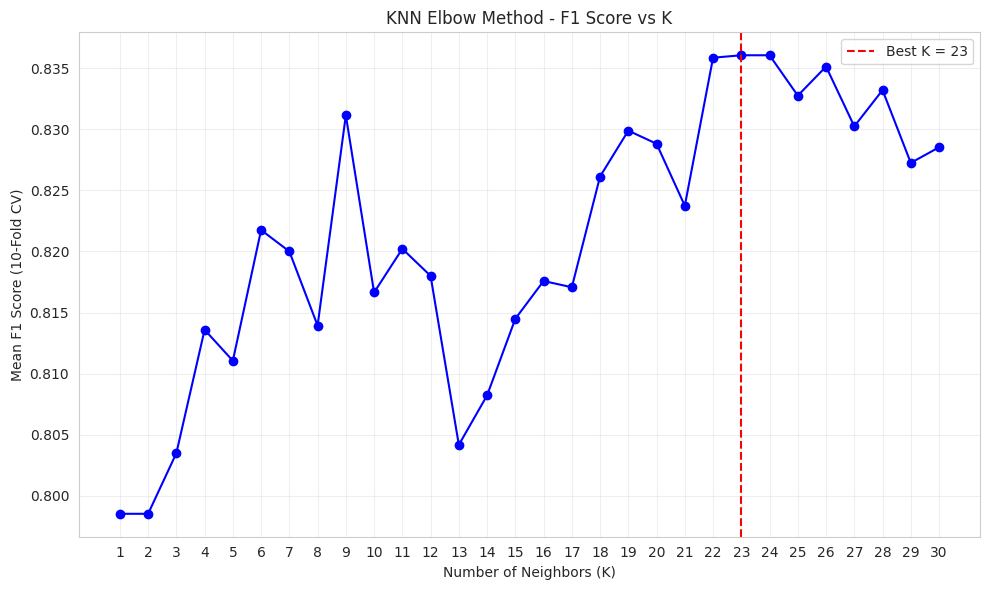

Elbow Method graph saved at: plots/knn_elbow_best_k.png

Metrics table saved to: plots/model_metrics_summary.csv

COMPREHENSIVE MODEL PERFORMANCE:
                   Model              Dataset  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Fit_Status
Logistic Regression (L2) Training (Cleveland)  0.844512   0.846626 0.841463  0.844037 0.930287   Train Set
Logistic Regression (L2)            Hungarian  0.840136   0.864198 0.660377  0.748663 0.893216    Good Fit
Logistic Regression (L2)          Switzerland  0.869919   0.954128 0.904348  0.928571 0.826087    Good Fit
Logistic Regression (L2)                   VA  0.670000   0.807407 0.731544  0.767606 0.646401 Overfitting
         KNN (Best K=23) Training (Cleveland)  1.000000   1.000000 1.000000  1.000000 1.000000   Train Set
         KNN (Best K=23)            Hungarian  0.816327   0.851351 0.594340  0.700000 0.903377 Overfitting
         KNN (Best K=23)          Switzerland  0.780488   0.958333 0.800000  0.872038 0.779348 Overfitti

In [ ]:

from sklearn.model_selection import cross_val_score

# ------------------------------
# 15.1 KNN - 10-Fold CV to find Best K (Elbow Method)
# ------------------------------
k_range = range(1, 31)
cv_f1_scores = []

print("\nRunning 10-Fold Cross-Validation for KNN (Elbow Method)...")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(
        knn,
        X_train_balanced,
        y_train_balanced,
        cv=10,
        scoring='f1',
        n_jobs=-1
    )
    cv_f1_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_f1_scores)]
print(f"Optimal K found using Elbow Method (10-Fold CV): {best_k}")

plt.figure(figsize=(10,6))
plt.plot(k_range, cv_f1_scores, marker='o', linestyle='-', color='blue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN Elbow Method - F1 Score vs K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean F1 Score (10-Fold CV)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Always show graph
plt.show()

# Save the figure as well
elbow_fname = os.path.join(PLOT_DIR, 'knn_elbow_best_k.png')
plt.savefig(elbow_fname, dpi=300)
plt.close()
print(f"Elbow Method graph saved at: {elbow_fname}")

# ------------------------------
# 15.2 Retrain KNN with Best K
# ------------------------------
best_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
best_knn.fit(X_train_balanced, y_train_balanced)

# ------------------------------
# 15.3 Helper Function to Evaluate Models
# ------------------------------
def evaluate_and_store(model, model_name, X_test_dict, y_test_dict, X_train=None, y_train=None):
    results = []

    # Training metrics
    train_metrics = None
    if X_train is not None and y_train is not None:
        y_train_pred = model.predict(X_train)
        y_train_proba = model.predict_proba(X_train)[:,1] if hasattr(model,'predict_proba') else y_train_pred

        train_acc = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred)
        train_rec = recall_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred)
        train_auc = roc_auc_score(y_train, y_train_proba)

        train_metrics = {
            'Model': model_name,
            'Dataset': 'Training (Cleveland)',
            'Train_Acc': train_acc,
            'Test_Acc': train_acc,
            'Fit_Status': 'Train Set',
            'Accuracy': train_acc,
            'Precision': train_prec,
            'Recall': train_rec,
            'F1-Score': train_f1,
            'AUC-ROC': train_auc
        }
        results.append(train_metrics)

    # Testing metrics
    for tname, X_t in X_test_dict.items():
        y_t = y_test_dict[tname]
        y_pred = model.predict(X_t)
        y_proba = model.predict_proba(X_t)[:,1] if hasattr(model,'predict_proba') else y_pred

        acc = accuracy_score(y_t, y_pred)
        prec = precision_score(y_t, y_pred)
        rec = recall_score(y_t, y_pred)
        f1 = f1_score(y_t, y_pred)
        auc = roc_auc_score(y_t, y_proba)

        fit_status = "N/A"
        train_acc_val = None
        if train_metrics is not None:
            train_acc_val = train_metrics['Accuracy']
            diff = train_acc_val - acc
            if abs(diff) < 0.05:
                fit_status = "Good Fit"
            elif diff >= 0.05:
                fit_status = "Overfitting"
            else:
                if acc < 0.60 and train_acc_val < 0.70:
                    fit_status = "Underfitting"
                else:
                    fit_status = "Good Fit"

        results.append({
            'Model': model_name,
            'Dataset': tname,
            'Train_Acc': train_acc_val,
            'Test_Acc': acc,
            'Fit_Status': fit_status,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC-ROC': auc
        })

    return results

# ------------------------------
# 15.4 Evaluate All Models
# ------------------------------
all_metrics = []

# Logistic Regression (best L2)
all_metrics.extend(evaluate_and_store(best, 'Logistic Regression (L2)', X_tests, y_tests, X_train_balanced, y_train_balanced))

# KNN with best K
all_metrics.extend(evaluate_and_store(best_knn, f'KNN (Best K={best_k})', X_tests, y_tests, X_train_balanced, y_train_balanced))

# Decision Tree
all_metrics.extend(evaluate_and_store(best_dt, 'Decision Tree', X_tests, y_tests, X_train_balanced, y_train_balanced))

# Naive Bayes
all_metrics.extend(evaluate_and_store(nb, 'Naive Bayes', X_tests, y_tests, X_train_balanced, y_train_balanced))

# SVM
all_metrics.extend(evaluate_and_store(best_svm, 'SVM', X_tests, y_tests, X_train_balanced, y_train_balanced))

# Voting Ensemble
all_metrics.extend(evaluate_and_store(voting_clf, 'Voting Ensemble', X_tests, y_tests, X_train_balanced, y_train_balanced))

# ------------------------------
# 15.5 Create Metrics DataFrame
# ------------------------------
metrics_df = pd.DataFrame(all_metrics)

csv_filename = os.path.join(PLOT_DIR, 'model_metrics_summary.csv')
metrics_df.to_csv(csv_filename, index=False)
print(f"\nMetrics table saved to: {csv_filename}")

# Split Training vs Testing
training_df = metrics_df[metrics_df['Dataset'] == 'Training (Cleveland)']
testing_df = metrics_df[metrics_df['Dataset'] != 'Training (Cleveland)']

# ------------------------------
# 15.6 Display Metrics Tables
# ------------------------------
print("\nCOMPREHENSIVE MODEL PERFORMANCE:")
print(metrics_df[['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Fit_Status']].to_string(index=False))

# ------------------------------
# 15.7 Plot Train vs Avg Test Accuracy
# ------------------------------
if len(training_df) > 0 and len(testing_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 7))

    models = metrics_df['Model'].unique()
    train_accs, avg_test_accs, model_names_list = [], [], []

    for model in models:
        train_data = training_df[training_df['Model'] == model]
        test_data = testing_df[testing_df['Model'] == model]

        if len(train_data) > 0:
            train_acc = train_data['Accuracy'].iloc[0]
            avg_test_acc = test_data['Accuracy'].mean() if len(test_data) > 0 else train_acc
            train_accs.append(train_acc)
            avg_test_accs.append(avg_test_acc)
            model_names_list.append(model)

    x = np.arange(len(model_names_list))
    width = 0.35

    bars1 = ax.bar(x - width/2, train_accs, width, label='Training (Cleveland)', color='#2196F3', alpha=0.8)
    bars2 = ax.bar(x + width/2, avg_test_accs, width, label='Avg Testing (Hungarian/Switzerland/VA)', color='#FF9800', alpha=0.8)

    ax.set_xlabel('Models', fontsize=12, weight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, weight='bold')
    ax.set_title('Training vs Testing Accuracy - Overfitting/Underfitting', fontsize=14, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_list, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    fname_overfit = os.path.join(PLOT_DIR, 'train_vs_test_accuracy.png')
    if DISPLAY_PLOTS:
        plt.show()
    plt.savefig(fname_overfit, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"Train vs Test accuracy comparison saved to: {fname_overfit}")

# ------------------------------
# 15.8 Overfitting/Underfitting Analysis Table
# ------------------------------
analysis_data = []
for model in metrics_df['Model'].unique():
    train_data = training_df[training_df['Model'] == model]
    test_data = testing_df[testing_df['Model'] == model]

    if len(train_data) > 0 and len(test_data) > 0:
        train_acc = train_data['Accuracy'].iloc[0]
        avg_test_acc = test_data['Accuracy'].mean()
        diff = train_acc - avg_test_acc
        if abs(diff) < 0.05:
            fit_status = "Good Fit"
        elif diff >= 0.05:
            fit_status = "Overfitting"
        else:
            if avg_test_acc < 0.60 and train_acc < 0.70:
                fit_status = "Underfitting"
            else:
                fit_status = "Good Fit"
        analysis_data.append({
            'Model': model,
            'Training_Acc': f'{train_acc:.4f}',
            'Avg_Testing_Acc': f'{avg_test_acc:.4f}',
            'Difference': f'{diff:.4f}',
            'Status': fit_status
        })

analysis_df = pd.DataFrame(analysis_data)
print("\nOVERFITTING/UNDERFITTING ANALYSIS SUMMARY")
print(analysis_df.to_string(index=False))



Step 16: Generating Confusion Matrices, ROC Curves, and Feature Plots for all models...

Processing model: Logistic Regression (L2)


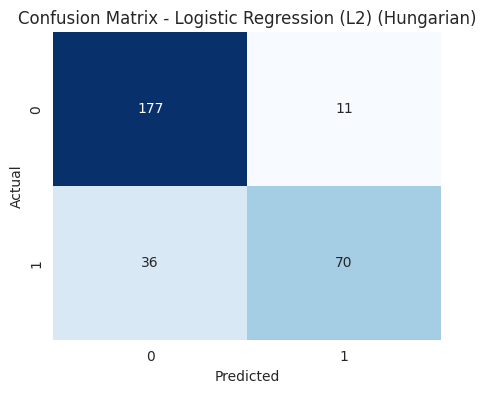

Saved: plots/cm_Logistic_Regression_(L2)_Hungarian.png


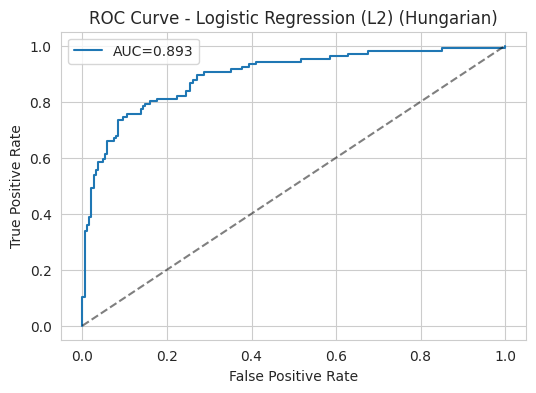

Saved: plots/roc_Logistic_Regression_(L2)_Hungarian.png


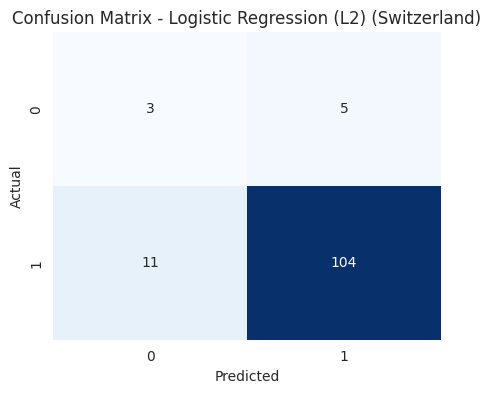

Saved: plots/cm_Logistic_Regression_(L2)_Switzerland.png


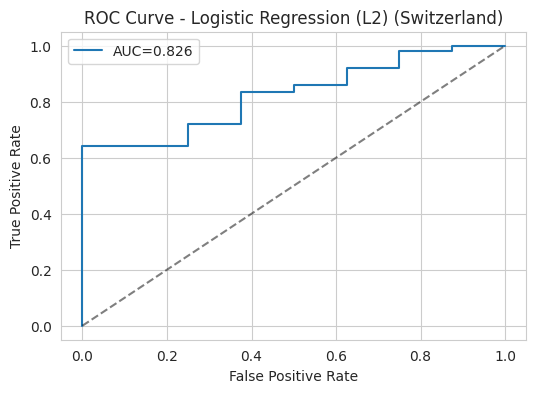

Saved: plots/roc_Logistic_Regression_(L2)_Switzerland.png


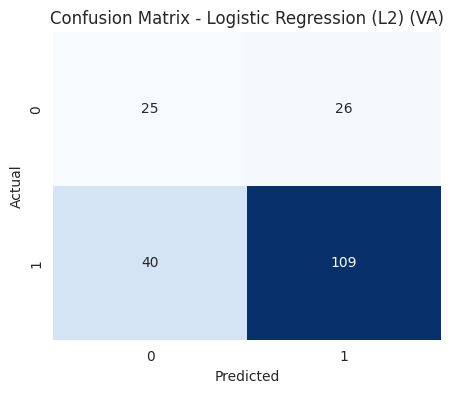

Saved: plots/cm_Logistic_Regression_(L2)_VA.png


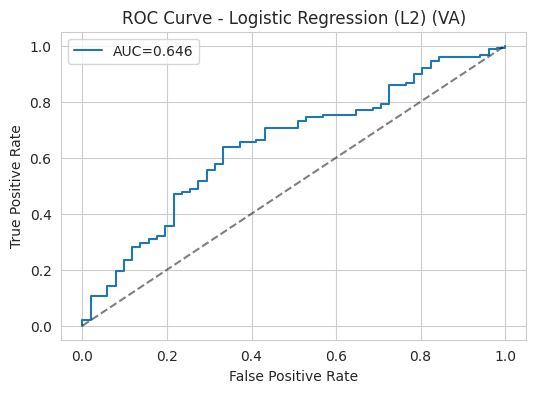

Saved: plots/roc_Logistic_Regression_(L2)_VA.png


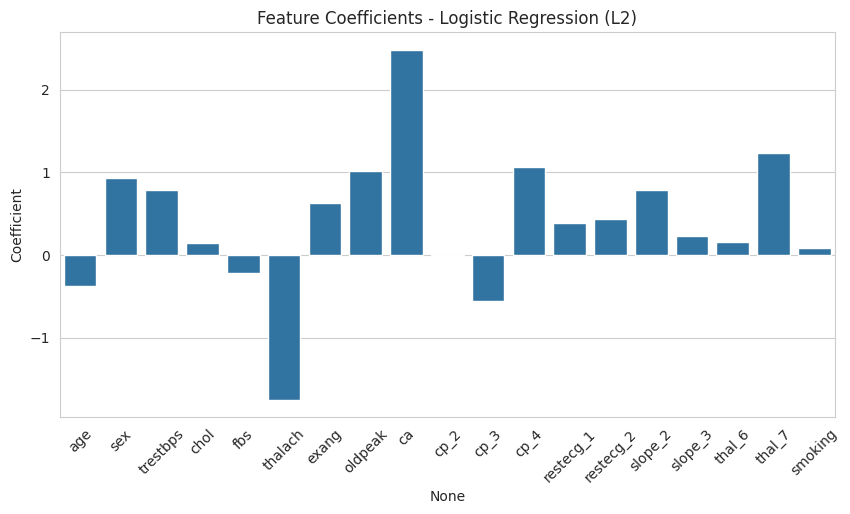

Saved: plots/feature_coeff_Logistic_Regression_(L2).png

Processing model: KNN


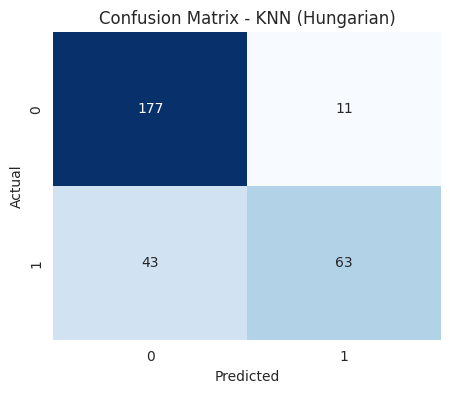

Saved: plots/cm_KNN_Hungarian.png


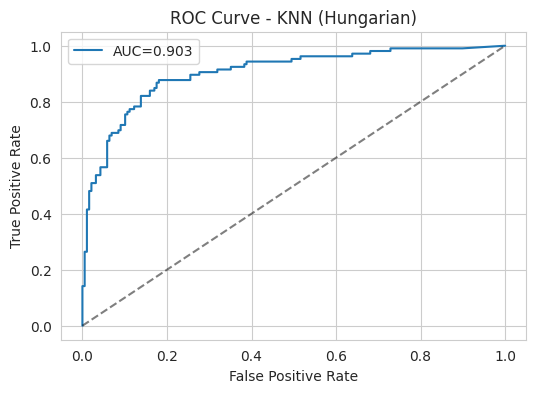

Saved: plots/roc_KNN_Hungarian.png


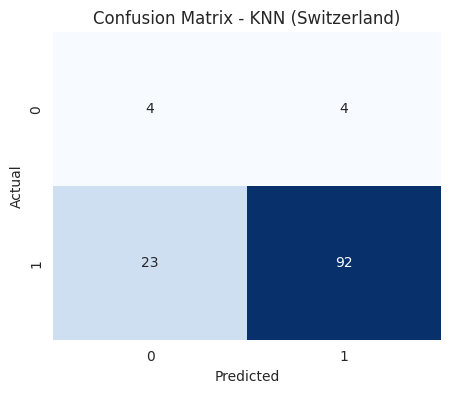

Saved: plots/cm_KNN_Switzerland.png


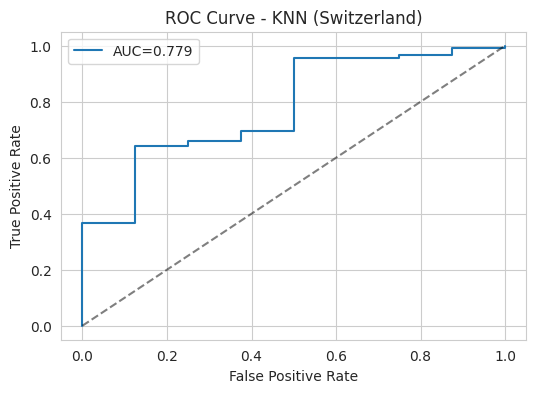

Saved: plots/roc_KNN_Switzerland.png


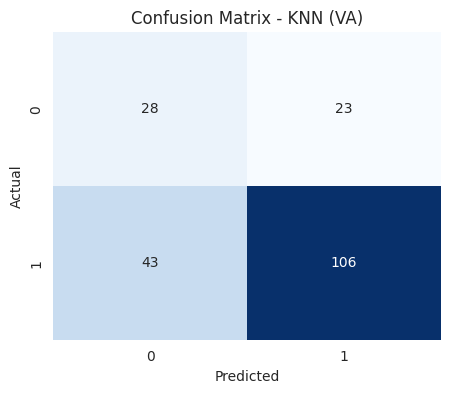

Saved: plots/cm_KNN_VA.png


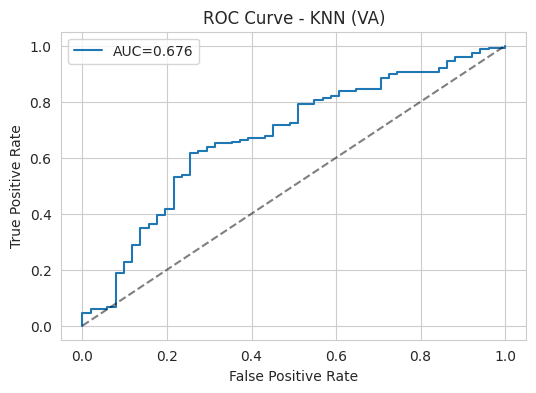

Saved: plots/roc_KNN_VA.png

Processing model: Decision Tree


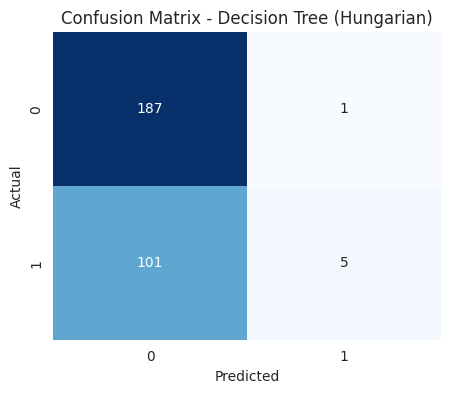

Saved: plots/cm_Decision_Tree_Hungarian.png


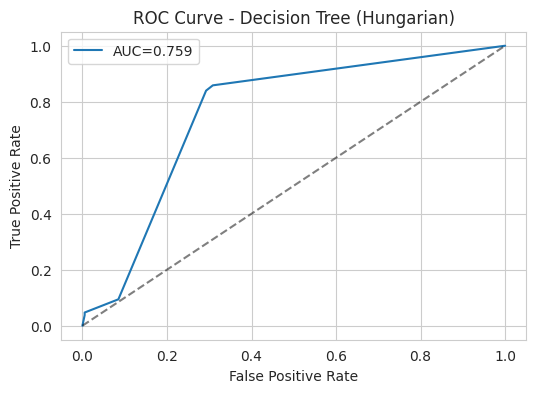

Saved: plots/roc_Decision_Tree_Hungarian.png


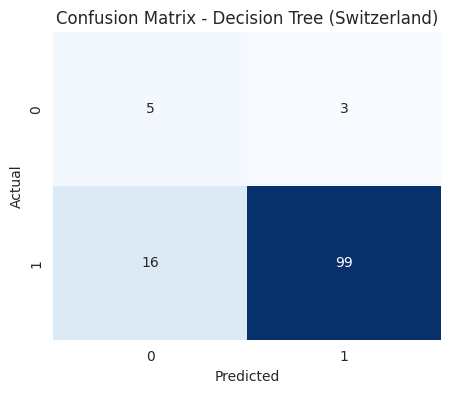

Saved: plots/cm_Decision_Tree_Switzerland.png


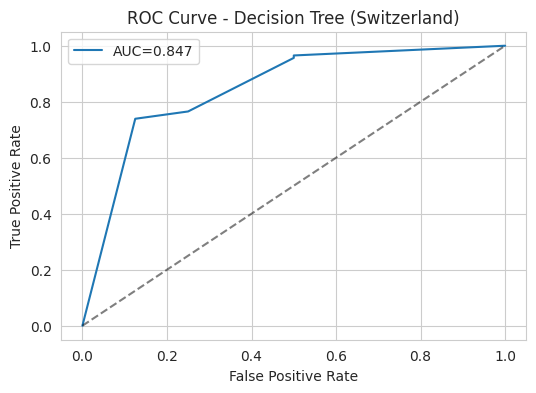

Saved: plots/roc_Decision_Tree_Switzerland.png


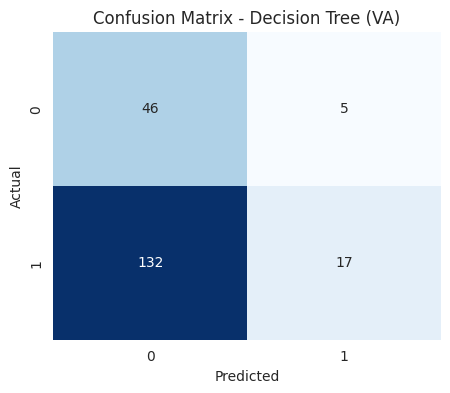

Saved: plots/cm_Decision_Tree_VA.png


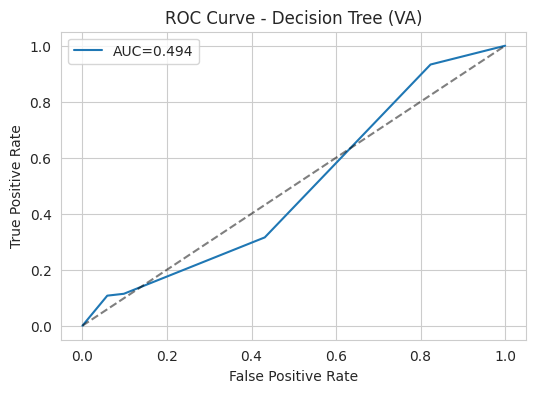

Saved: plots/roc_Decision_Tree_VA.png


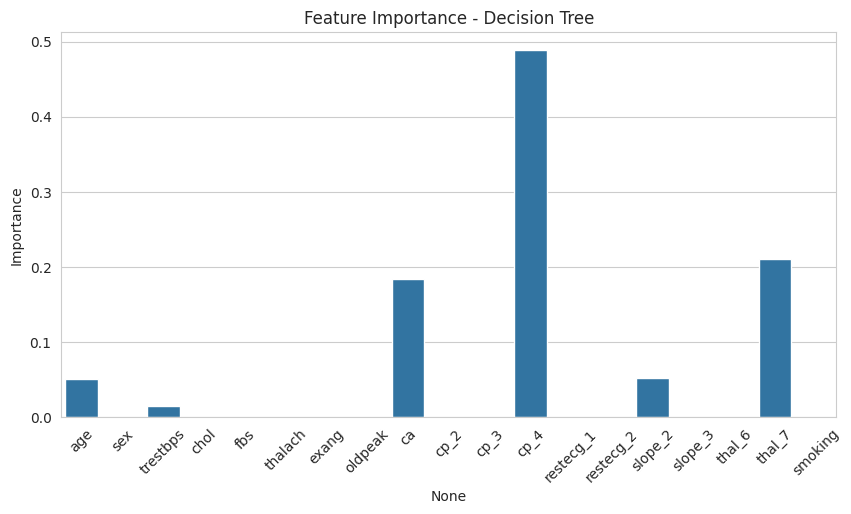

Saved: plots/feature_importance_Decision_Tree.png

Processing model: Naive Bayes


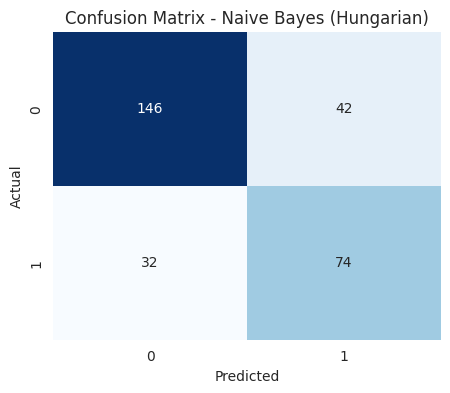

Saved: plots/cm_Naive_Bayes_Hungarian.png


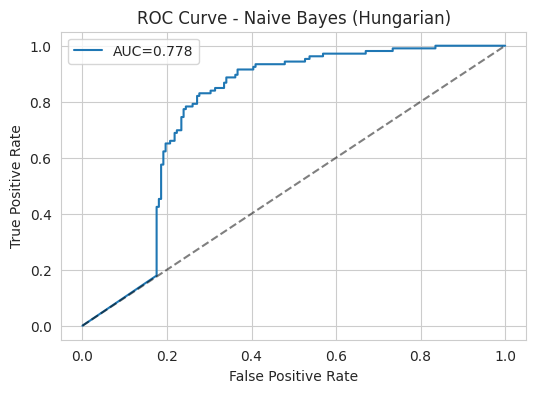

Saved: plots/roc_Naive_Bayes_Hungarian.png


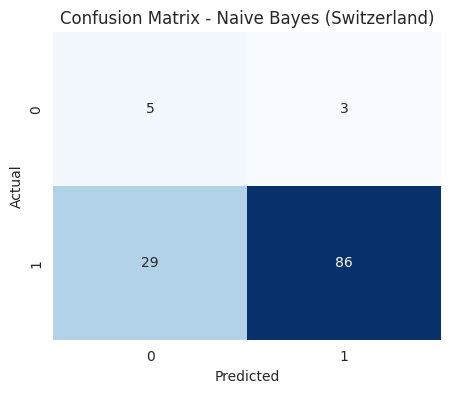

Saved: plots/cm_Naive_Bayes_Switzerland.png


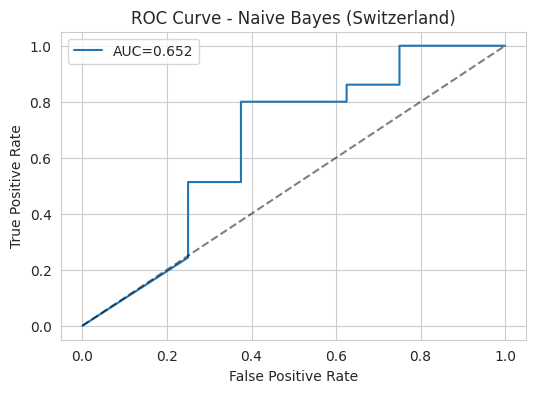

Saved: plots/roc_Naive_Bayes_Switzerland.png


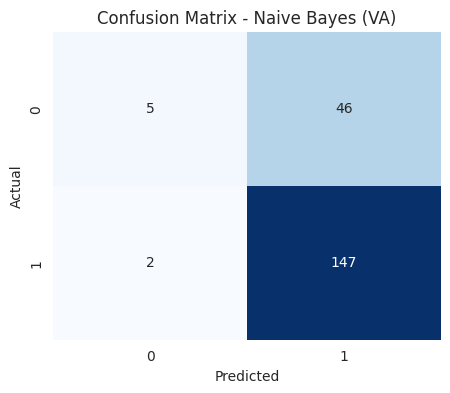

Saved: plots/cm_Naive_Bayes_VA.png


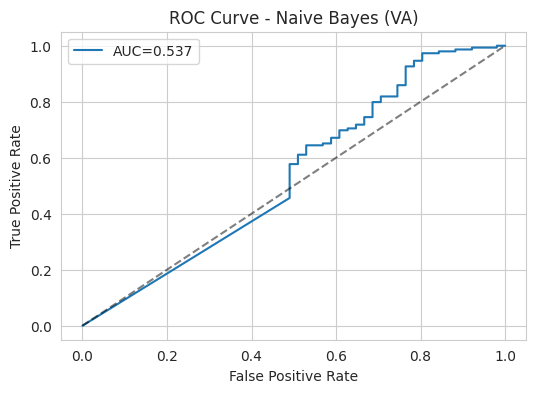

Saved: plots/roc_Naive_Bayes_VA.png


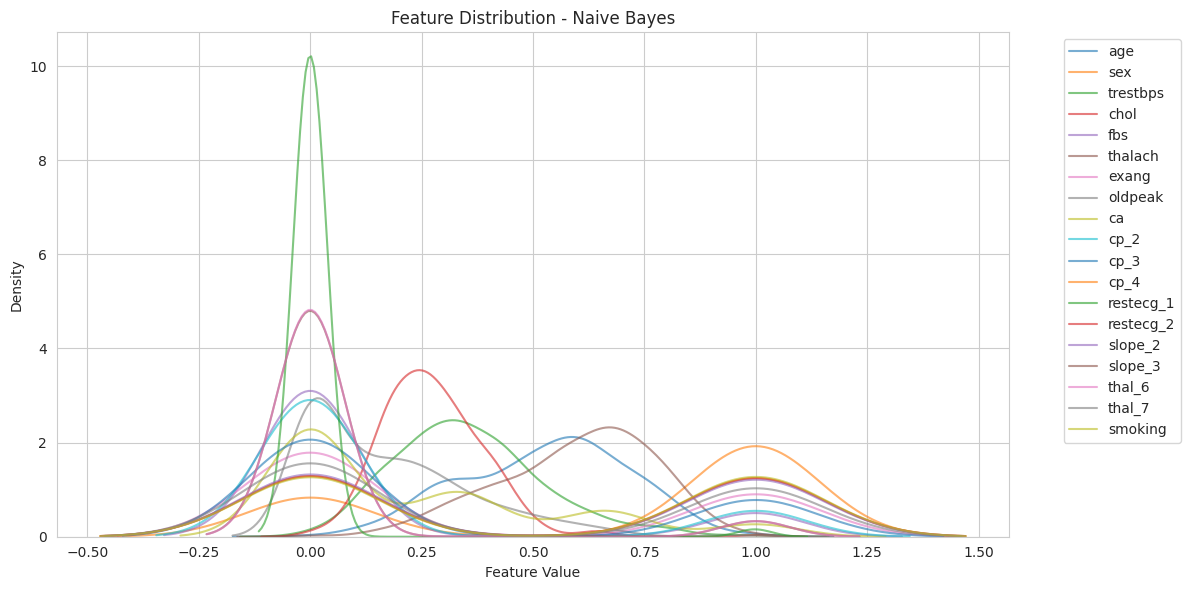

Saved: plots/feature_distribution_Naive_Bayes.png

Processing model: SVM


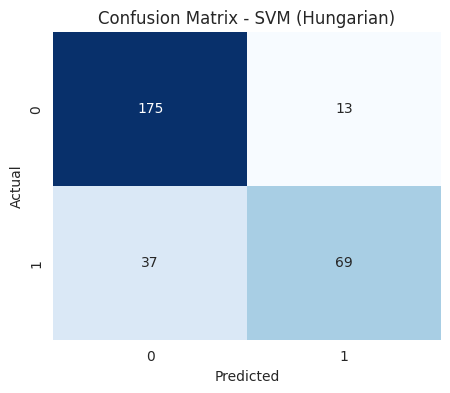

Saved: plots/cm_SVM_Hungarian.png


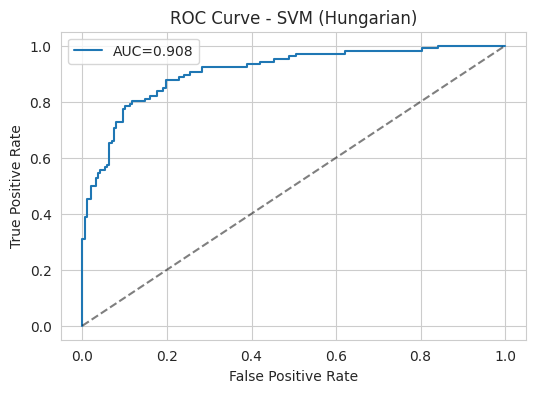

Saved: plots/roc_SVM_Hungarian.png


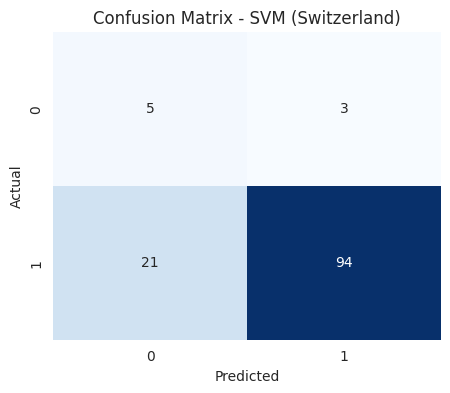

Saved: plots/cm_SVM_Switzerland.png


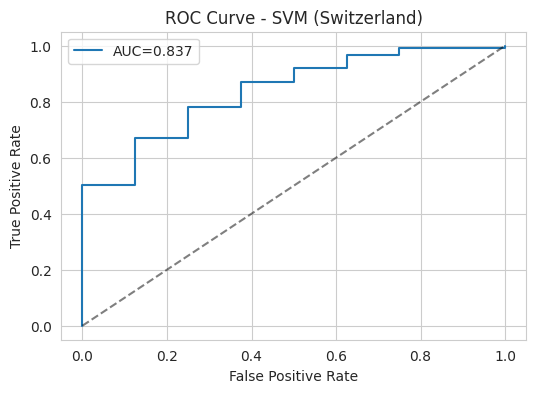

Saved: plots/roc_SVM_Switzerland.png


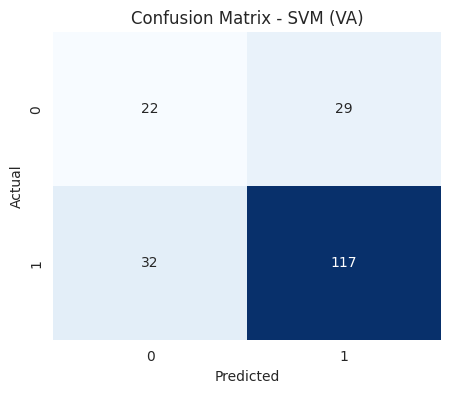

Saved: plots/cm_SVM_VA.png


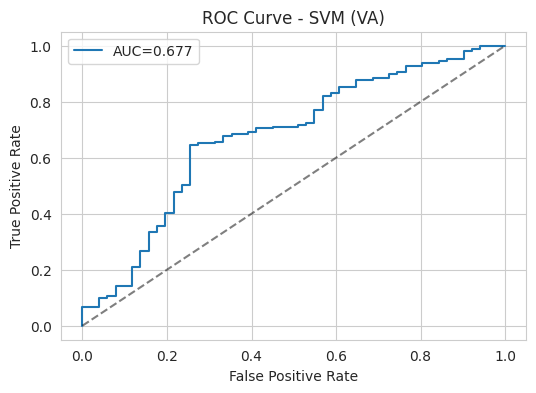

Saved: plots/roc_SVM_VA.png

Processing model: Voting Ensemble


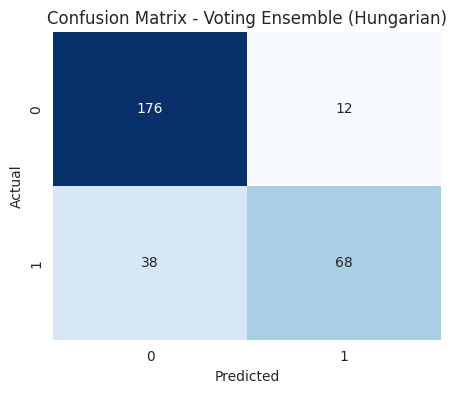

Saved: plots/cm_Voting_Ensemble_Hungarian.png


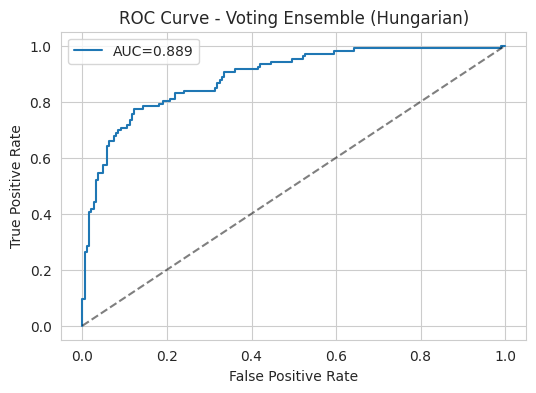

Saved: plots/roc_Voting_Ensemble_Hungarian.png


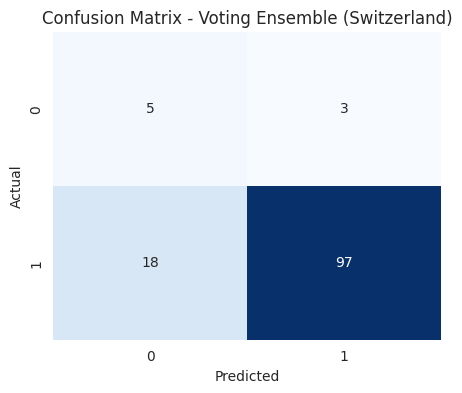

Saved: plots/cm_Voting_Ensemble_Switzerland.png


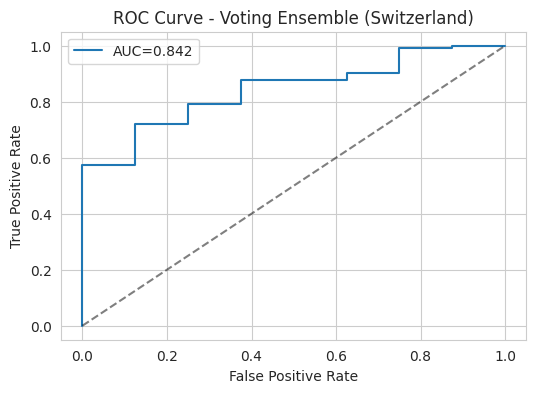

Saved: plots/roc_Voting_Ensemble_Switzerland.png


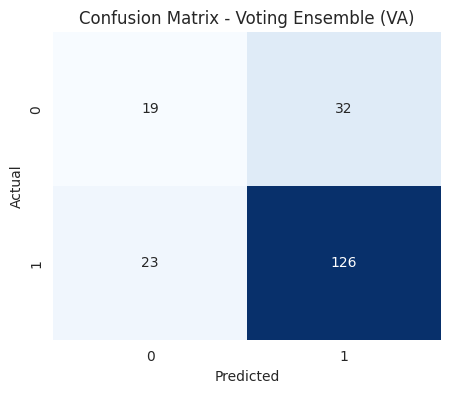

Saved: plots/cm_Voting_Ensemble_VA.png


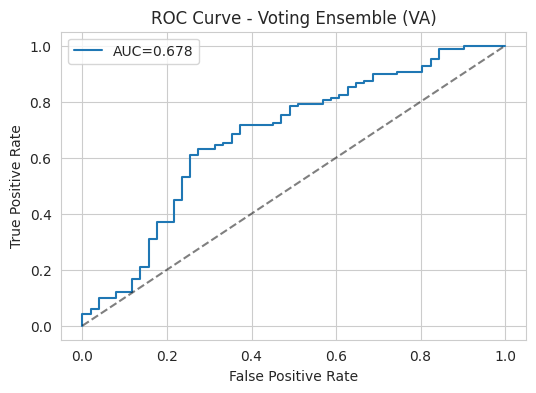

Saved: plots/roc_Voting_Ensemble_VA.png

Step 16 completed: All plots for Confusion Matrix, ROC, and Feature Importance/Distribution saved AND displayed.


In [ ]:
# =========================================================
# 16. Model Evaluation and Visualization (Confusion, ROC, Feature Importance) - SHOW & SAVE
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import os

os.makedirs(PLOT_DIR, exist_ok=True)

models_dict = {
    'Logistic Regression (L2)': best,
    'KNN': best_knn,
    'Decision Tree': best_dt,
    'Naive Bayes': nb,
    'SVM': best_svm,
    'Voting Ensemble': voting_clf
}

DISPLAY_PLOTS = True  # <-- Change to False to hide plots (only save)

print("\nStep 16: Generating Confusion Matrices, ROC Curves, and Feature Plots for all models...")

for model_name, model in models_dict.items():
    print(f"\nProcessing model: {model_name}")

    for tname, X_t in X_tests.items():
        y_t = y_tests[tname]
        y_pred = model.predict(X_t)
        y_proba = model.predict_proba(X_t)[:,1] if hasattr(model, 'predict_proba') else y_pred

        # ===== Confusion Matrix =====
        cm = confusion_matrix(y_t, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix - {model_name} ({tname})')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        cm_file = os.path.join(PLOT_DIR, f'cm_{model_name.replace(" ","_")}_{tname}.png')
        plt.savefig(cm_file, bbox_inches='tight', dpi=300)
        if DISPLAY_PLOTS:
            plt.show()
        plt.close()
        print(f"Saved: {cm_file}")

        # ===== ROC Curve =====
        fpr, tpr, _ = roc_curve(y_t, y_proba)
        auc = roc_auc_score(y_t, y_proba)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0,1], [0,1], 'k--', alpha=0.5)
        plt.title(f'ROC Curve - {model_name} ({tname})')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        roc_file = os.path.join(PLOT_DIR, f'roc_{model_name.replace(" ","_")}_{tname}.png')
        plt.savefig(roc_file, bbox_inches='tight', dpi=300)
        if DISPLAY_PLOTS:
            plt.show()
        plt.close()
        print(f"Saved: {roc_file}")

    # ===== Feature Importance / Distribution =====
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        plt.figure(figsize=(10,5))
        sns.barplot(x=X_train.columns, y=importances)
        plt.xticks(rotation=45)
        plt.title(f'Feature Importance - {model_name}')
        plt.ylabel('Importance')
        fi_file = os.path.join(PLOT_DIR, f'feature_importance_{model_name.replace(" ","_")}.png')
        plt.savefig(fi_file, bbox_inches='tight', dpi=300)
        if DISPLAY_PLOTS:
            plt.show()
        plt.close()
        print(f"Saved: {fi_file}")

    elif hasattr(model, 'coef_'):
        coef = model.coef_[0]
        plt.figure(figsize=(10,5))
        sns.barplot(x=X_train.columns, y=coef)
        plt.xticks(rotation=45)
        plt.title(f'Feature Coefficients - {model_name}')
        plt.ylabel('Coefficient')
        coef_file = os.path.join(PLOT_DIR, f'feature_coeff_{model_name.replace(" ","_")}.png')
        plt.savefig(coef_file, bbox_inches='tight', dpi=300)
        if DISPLAY_PLOTS:
            plt.show()
        plt.close()
        print(f"Saved: {coef_file}")

    elif model_name == 'Naive Bayes':
        plt.figure(figsize=(12,6))
        for i, col in enumerate(X_train.columns):
            sns.kdeplot(X_train_balanced[col], label=col, fill=False, alpha=0.6)
        plt.title(f'Feature Distribution - {model_name}')
        plt.xlabel('Feature Value')
        plt.ylabel('Density')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        nb_file = os.path.join(PLOT_DIR, f'feature_distribution_{model_name.replace(" ","_")}.png')
        plt.tight_layout()
        plt.savefig(nb_file, bbox_inches='tight', dpi=300)
        if DISPLAY_PLOTS:
            plt.show()
        plt.close()
        print(f"Saved: {nb_file}")

print("\nStep 16 completed: All plots for Confusion Matrix, ROC, and Feature Importance/Distribution saved AND displayed.")



Step 17: Detailed metrics table saved to plots/step17_detailed_metrics.csv


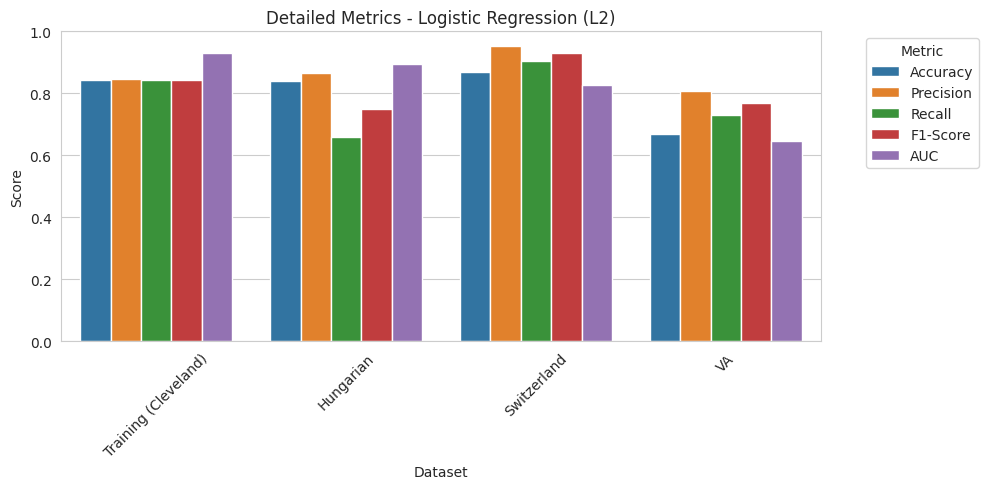

Saved plot: plots/detailed_metrics_Logistic_Regression_(L2).png


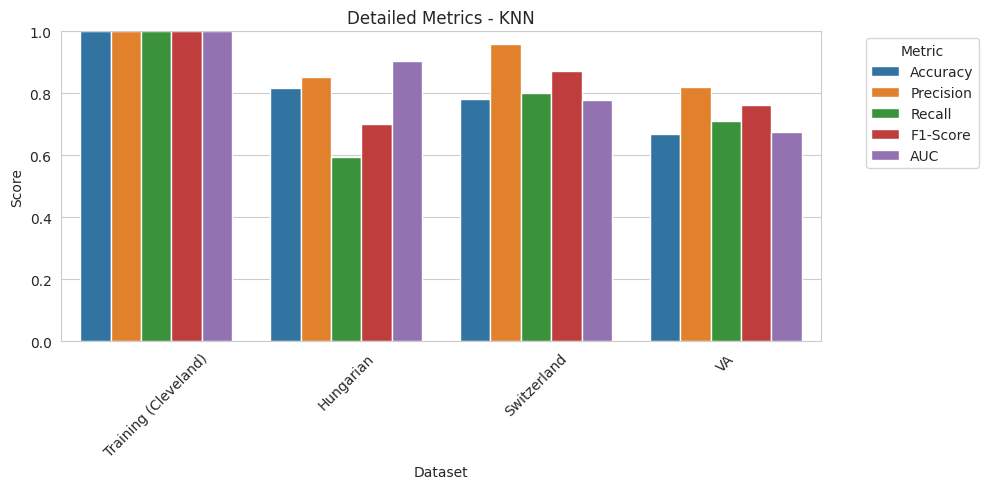

Saved plot: plots/detailed_metrics_KNN.png


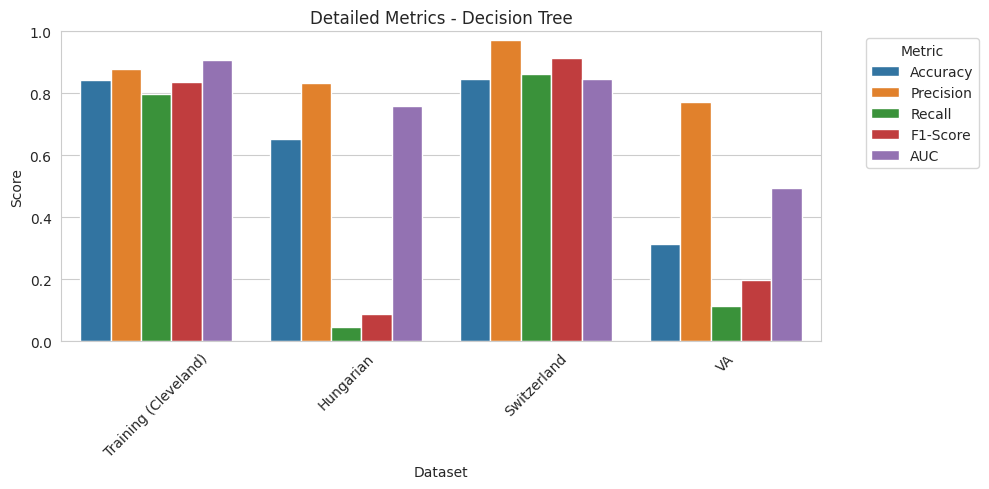

Saved plot: plots/detailed_metrics_Decision_Tree.png


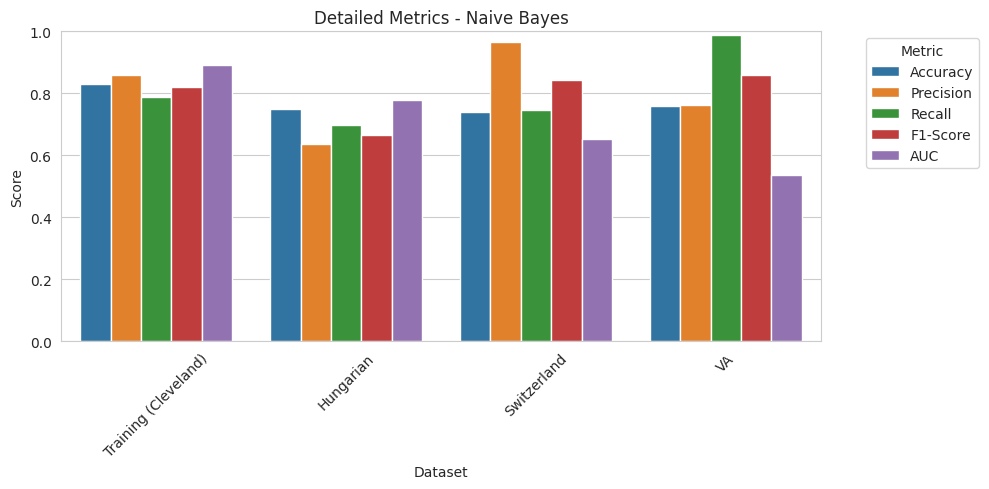

Saved plot: plots/detailed_metrics_Naive_Bayes.png


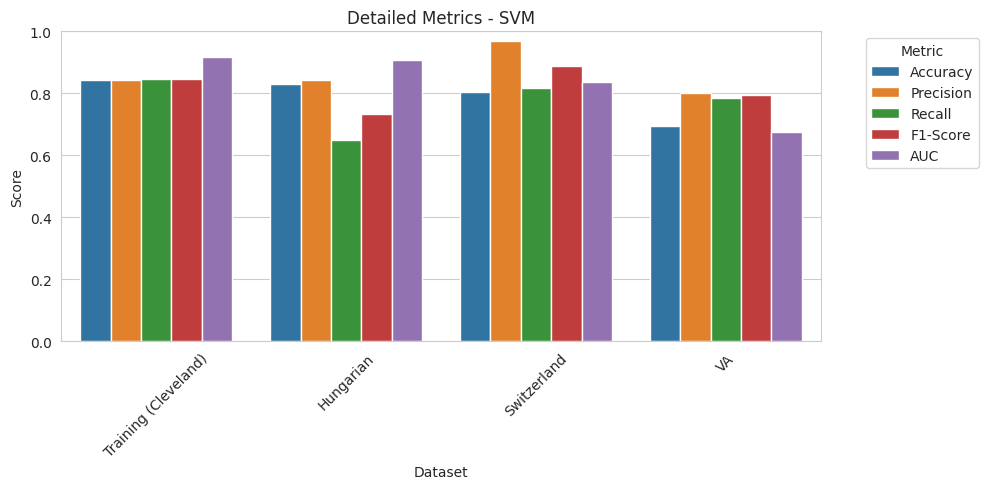

Saved plot: plots/detailed_metrics_SVM.png


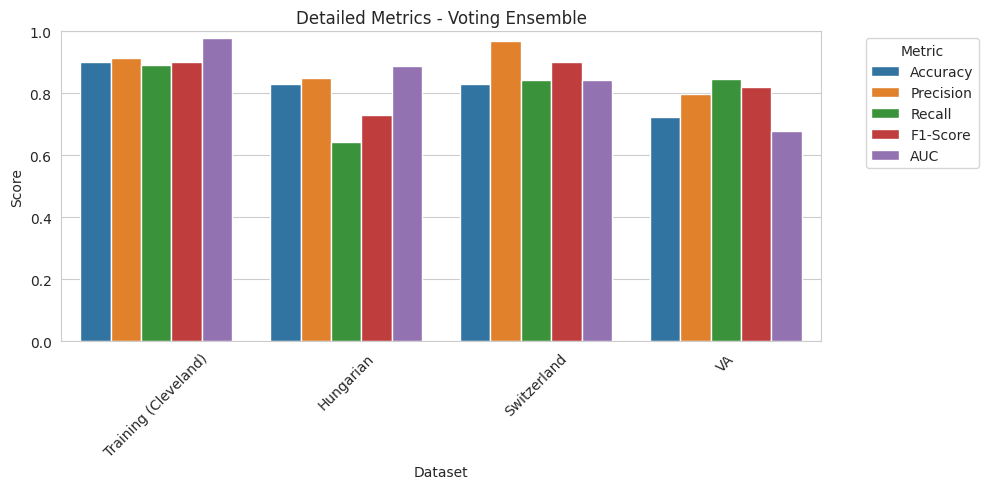

Saved plot: plots/detailed_metrics_Voting_Ensemble.png

Step 17 completed: All metrics saved and plots generated.


In [ ]:
# =========================================================
# 17. Detailed Metrics Table & Plots per Model per Dataset
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

os.makedirs(PLOT_DIR, exist_ok=True)
DISPLAY_PLOTS = True  # Set to False if you don't want to show plots

# Models dictionary
models_dict = {
    'Logistic Regression (L2)': best,
    'KNN': best_knn,
    'Decision Tree': best_dt,
    'Naive Bayes': nb,
    'SVM': best_svm,
    'Voting Ensemble': voting_clf
}

all_metrics_list = []

# Collect metrics for each model, training dataset, and each testing dataset
for model_name, model in models_dict.items():

    # ---------- Training Dataset ----------
    y_train_pred = model.predict(X_train_balanced)
    y_train_proba = model.predict_proba(X_train_balanced)[:,1] if hasattr(model,'predict_proba') else y_train_pred

    train_metrics = {
        'Model': model_name,
        'Dataset': 'Training (Cleveland)',
        'Accuracy': accuracy_score(y_train_balanced, y_train_pred),
        'Precision': precision_score(y_train_balanced, y_train_pred),
        'Recall': recall_score(y_train_balanced, y_train_pred),
        'F1-Score': f1_score(y_train_balanced, y_train_pred),
        'AUC': roc_auc_score(y_train_balanced, y_train_proba)
    }
    all_metrics_list.append(train_metrics)

    # ---------- Testing Datasets ----------
    for tname, X_t in X_tests.items():
        y_t = y_tests[tname]
        y_pred = model.predict(X_t)
        y_proba = model.predict_proba(X_t)[:,1] if hasattr(model,'predict_proba') else y_pred

        test_metrics = {
            'Model': model_name,
            'Dataset': tname,
            'Accuracy': accuracy_score(y_t, y_pred),
            'Precision': precision_score(y_t, y_pred),
            'Recall': recall_score(y_t, y_pred),
            'F1-Score': f1_score(y_t, y_pred),
            'AUC': roc_auc_score(y_t, y_proba)
        }
        all_metrics_list.append(test_metrics)

# Convert to DataFrame
metrics_df = pd.DataFrame(all_metrics_list)

# Save CSV
csv_file = os.path.join(PLOT_DIR, 'step17_detailed_metrics.csv')
metrics_df.to_csv(csv_file, index=False)
print(f"\nStep 17: Detailed metrics table saved to {csv_file}")

# ---------- Plotting Metrics per Model ----------
for model_name in metrics_df['Model'].unique():
    model_data = metrics_df[metrics_df['Model'] == model_name]

    plt.figure(figsize=(10,5))
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    sns.barplot(
        data=model_data.melt(id_vars='Dataset', value_vars=metrics_to_plot),
        x='Dataset', y='value', hue='variable'
    )
    plt.ylim(0,1)
    plt.title(f'Detailed Metrics - {model_name}')
    plt.ylabel('Score')
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    plot_file = os.path.join(PLOT_DIR, f'detailed_metrics_{model_name.replace(" ","_")}.png')
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    if DISPLAY_PLOTS:
        plt.show()
    plt.close()
    print(f"Saved plot: {plot_file}")

print("\nStep 17 completed: All metrics saved and plots generated.")


# Task
To perform unsupervised learning on the heart disease dataset, including K-Means, Hierarchical Clustering, and Gaussian Mixture Models, along with determining optimal parameters and visualizing the results.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# Ensure PLOT_DIR exists
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)
DISPLAY_PLOTS = True # Set to False to save plots without displaying them

print("Starting Unsupervised Learning Analysis...")

# 1. Prepare Data for Unsupervised Learning
# X_train_balanced and X_tests are already prepared from previous steps
# They are already feature-only dataframes, so we just need to make copies
# for clarity or if any further modifications are specific to unsupervised learning.

X_unsupervised_train = X_train_balanced.copy()
X_unsupervised_tests = {name: df.copy() for name, df in X_tests.items()}

print(f"\nPrepared training data for unsupervised learning (shape): {X_unsupervised_train.shape}")
for name, df in X_unsupervised_tests.items():
    print(f"Prepared testing data for unsupervised learning ({name} shape): {df.shape}")

# Reduce dimensionality for visualization using PCA
# Fit PCA on the training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_unsupervised_train)

# Transform test data using the PCA fitted on training data
X_tests_pca = {name: pca.transform(df) for name, df in X_unsupervised_tests.items()}

print(f"\nTraining data reduced to 2 principal components for visualization (shape): {X_train_pca.shape}")

# 2. K-Means Clustering with Optimal K Determination (Elbow Method & Silhouette Score)
print("\n--- K-Means Clustering ---")
max_k = 10
inertia = []
silhouette_scores = []
k_range = range(2, max_k + 1) # Start from 2 for silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_unsupervised_train)
    inertia.append(kmeans.inertia_)
    # Calculate silhouette score
    # Silhouette score requires at least 2 clusters and points not all in one cluster
    if len(np.unique(kmeans.labels_)) > 1:
        silhouette_scores.append(silhouette_score(X_unsupervised_train, kmeans.labels_))
    else:
        silhouette_scores.append(-1) # Placeholder for cases where silhouette cannot be computed

# Plotting Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Inertia)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

# Plotting Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'kmeans_optimal_k.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Determine optimal K based on plots (manual observation or automated choice, e.g., max silhouette)
# For automated choice, pick k with highest silhouette score
optimal_k_kmeans = k_range[np.argmax(silhouette_scores)]
print(f"Optimal K for K-Means (based on Silhouette Score): {optimal_k_kmeans}")

# Apply K-Means with optimal K
kmeans_optimal = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
clusters_kmeans = kmeans_optimal.fit_predict(X_unsupervised_train)

# Visualize K-Means clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(pca.transform(kmeans_optimal.cluster_centers_)[:, 0], pca.transform(kmeans_optimal.cluster_centers_)[:, 1],
            marker='X', s=200, color='red', label='Cluster Centers')
plt.title(f'K-Means Clustering (K={optimal_k_kmeans}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(scatter, ticks=range(optimal_k_kmeans), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'kmeans_clusters_k{optimal_k_kmeans}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# 3. Hierarchical Clustering
print("\n--- Hierarchical Clustering ---")

# Perform hierarchical clustering
linked = linkage(X_unsupervised_train, method='ward') # 'ward' minimizes the variance of the clusters being merged

# Plotting the dendrogram (may be very dense for large datasets, consider truncating)
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    labels=clusters_kmeans if optimal_k_kmeans else None, # Using K-Means labels for comparison if available
    distance_sort='descending',
    show_leaf_counts=True,
    truncate_mode='lastp', # Show only the last 'p' merged clusters
    p=optimal_k_kmeans if optimal_k_kmeans else 10 # Truncate to show 'optimal_k_kmeans' or 10 clusters
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.savefig(os.path.join(PLOT_DIR, 'hierarchical_dendrogram.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Apply AgglomerativeClustering with the same number of clusters as K-Means for comparison
hierarchical_optimal = AgglomerativeClustering(n_clusters=optimal_k_kmeans, affinity='euclidean', linkage='ward')
clusters_hierarchical = hierarchical_optimal.fit_predict(X_unsupervised_train)

# Visualize Hierarchical clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_hierarchical, cmap='viridis', s=50, alpha=0.8)
plt.title(f'Hierarchical Clustering (K={optimal_k_kmeans}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(optimal_k_kmeans), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'hierarchical_clusters_k{optimal_k_kmeans}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# 4. Gaussian Mixture Model (GMM) with EM
print("\n--- Gaussian Mixture Model (GMM) ---")

# Determine optimal number of components using BIC/AIC
n_components_range = range(2, max_k + 1)
bic = []
aic = []

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    gmm.fit(X_unsupervised_train)
    bic.append(gmm.bic(X_unsupervised_train))
    aic.append(gmm.aic(X_unsupervised_train))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_components_range, bic, marker='o')
plt.title('BIC for Optimal Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_components_range, aic, marker='o')
plt.title('AIC for Optimal Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('AIC Score')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'gmm_optimal_components.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Determine optimal components (choose component with lowest BIC/AIC)
optimal_components_gmm = n_components_range[np.argmin(bic)] # Using BIC for optimal choice
print(f"Optimal number of components for GMM (based on BIC): {optimal_components_gmm}")

# Apply GMM with optimal components
gmm_optimal = GaussianMixture(n_components=optimal_components_gmm, random_state=42, n_init=10)
gmm_optimal.fit(X_unsupervised_train)
clusters_gmm = gmm_optimal.predict(X_unsupervised_train)

# Visualize GMM clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_gmm, cmap='viridis', s=50, alpha=0.8)
plt.title(f'GMM Clustering (Components={optimal_components_gmm}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(optimal_components_gmm), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'gmm_clusters_comp{optimal_components_gmm}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# 5. Summarize the findings (This will be done in the final summary)
print("\nUnsupervised learning analysis complete. Visualizations saved to the 'plots/' directory.")
print(f"Optimal K-Means clusters: {optimal_k_kmeans}")
print(f"Optimal GMM components: {optimal_components_gmm}")
```

In [ ]:
X_unsupervised_train = X_train_balanced.copy()
X_unsupervised_tests = {name: df.copy() for name, df in X_tests.items()}

print("Created copies of training and testing data for unsupervised learning.")

Created copies of training and testing data for unsupervised learning.


In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensionality for visualization using PCA
# Fit PCA on the training data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_unsupervised_train)

# Transform test data using the PCA fitted on training data
X_tests_pca = {name: pca.transform(df) for name, df in X_unsupervised_tests.items()}

print(f"\nTraining data reduced to 2 principal components for visualization (shape): {X_train_pca.shape}")
for name, df_pca in X_tests_pca.items():
    print(f"Testing data reduced to 2 principal components for visualization ({name} shape): {df_pca.shape}")


Training data reduced to 2 principal components for visualization (shape): (328, 2)
Testing data reduced to 2 principal components for visualization (Hungarian shape): (294, 2)
Testing data reduced to 2 principal components for visualization (Switzerland shape): (123, 2)
Testing data reduced to 2 principal components for visualization (VA shape): (200, 2)


In [ ]:
print("\n--- K-Means Clustering ---")
max_k = 10
inertia = []
silhouette_scores = []
k_range = range(2, max_k + 1) # Start from 2 for silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_unsupervised_train)
    inertia.append(kmeans.inertia_)
    # Calculate silhouette score
    # Silhouette score requires at least 2 clusters and points not all in one cluster
    if len(np.unique(kmeans.labels_)) > 1:
        silhouette_scores.append(silhouette_score(X_unsupervised_train, kmeans.labels_))
    else:
        silhouette_scores.append(-1) # Placeholder for cases where silhouette cannot be computed

print("Inertia and Silhouette scores calculated for K-Means.")


--- K-Means Clustering ---
Inertia and Silhouette scores calculated for K-Means.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

print("\n--- K-Means Clustering ---")
max_k = 10
inertia = []
silhouette_scores = []
k_range = range(2, max_k + 1) # Start from 2 for silhouette_score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_unsupervised_train)
    inertia.append(kmeans.inertia_)
    # Calculate silhouette score
    # Silhouette score requires at least 2 clusters and points not all in one cluster
    if len(np.unique(kmeans.labels_)) > 1:
        silhouette_scores.append(silhouette_score(X_unsupervised_train, kmeans.labels_))
    else:
        silhouette_scores.append(-1) # Placeholder for cases where silhouette cannot be computed

print("Inertia and Silhouette scores calculated for K-Means.")


--- K-Means Clustering ---
Inertia and Silhouette scores calculated for K-Means.


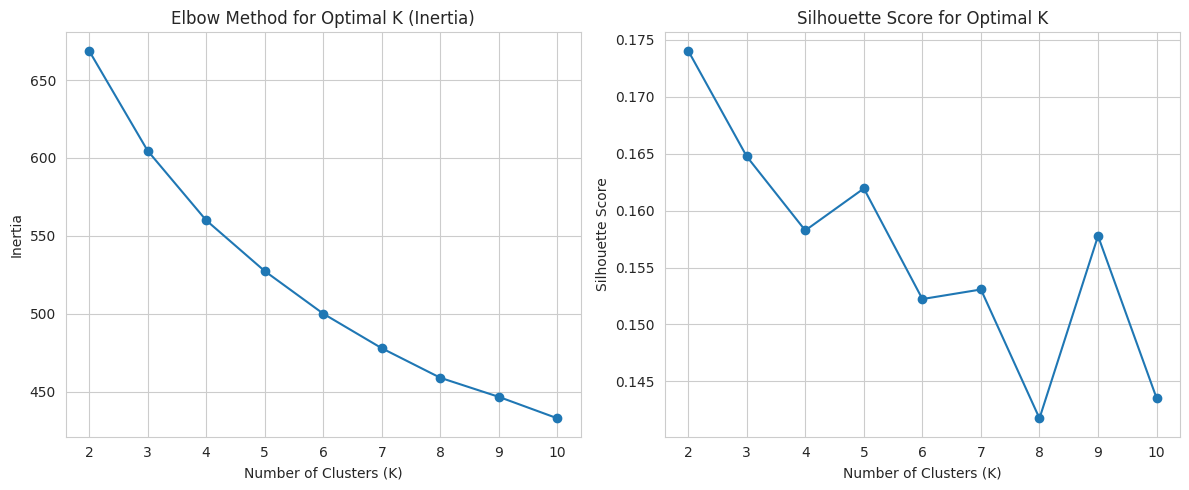

Optimal K for K-Means (based on Silhouette Score): 2


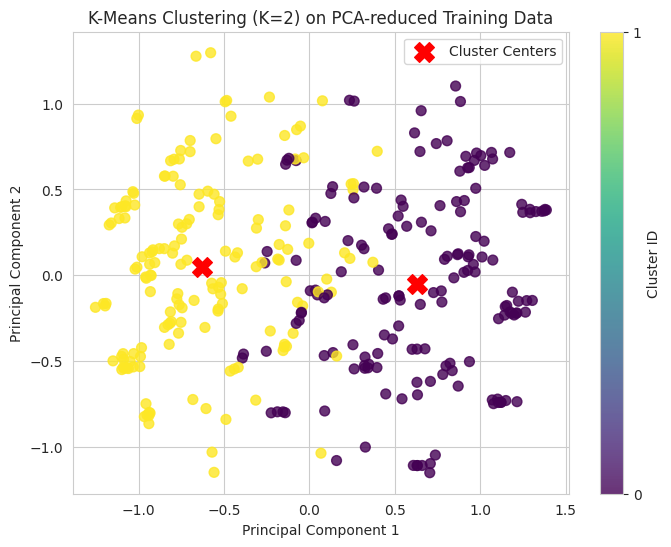

K-Means clustering with optimal K applied and visualized.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Elbow Method and Silhouette Score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Inertia)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'kmeans_optimal_k.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Determine optimal K based on plots (automated choice: max silhouette score)
optimal_k_kmeans = k_range[np.argmax(silhouette_scores)]
print(f"Optimal K for K-Means (based on Silhouette Score): {optimal_k_kmeans}")

# Apply K-Means with optimal K
kmeans_optimal = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
clusters_kmeans = kmeans_optimal.fit_predict(X_unsupervised_train)

# Visualize K-Means clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(pca.transform(kmeans_optimal.cluster_centers_)[:, 0], pca.transform(kmeans_optimal.cluster_centers_)[:, 1],
            marker='X', s=200, color='red', label='Cluster Centers')
plt.title(f'K-Means Clustering (K={optimal_k_kmeans}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.colorbar(scatter, ticks=range(optimal_k_kmeans), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'kmeans_clusters_k{optimal_k_kmeans}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("K-Means clustering with optimal K applied and visualized.")


--- Hierarchical Clustering ---


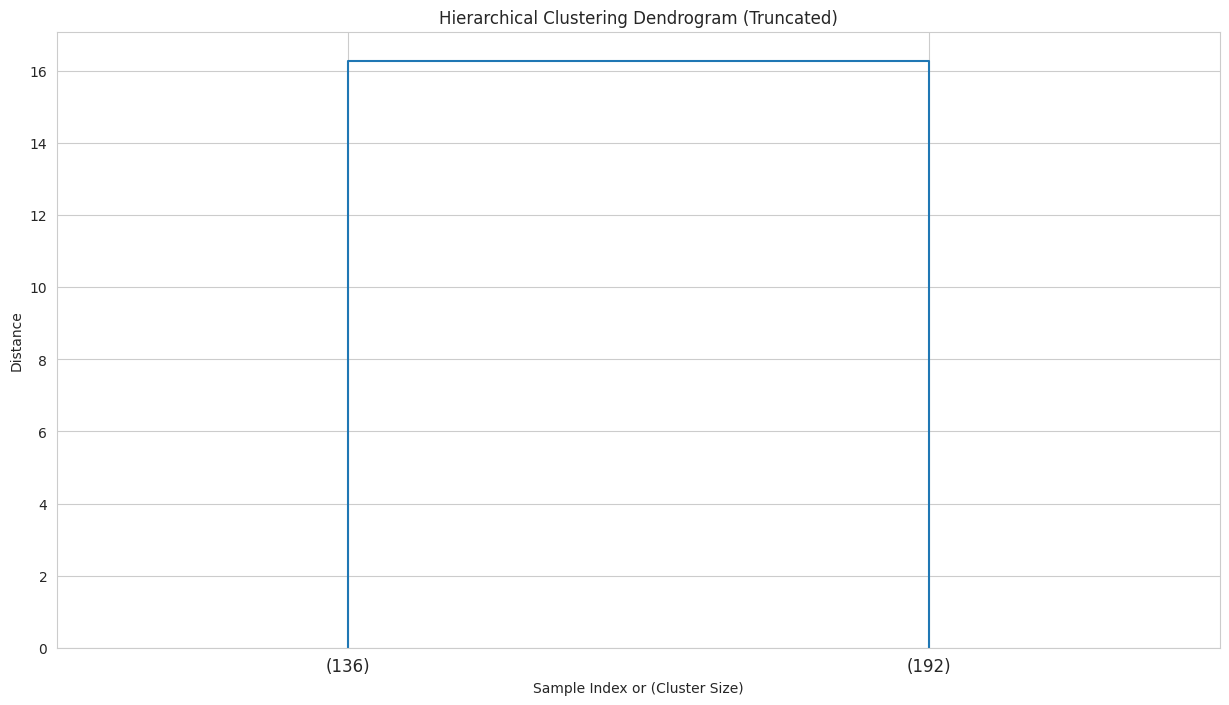

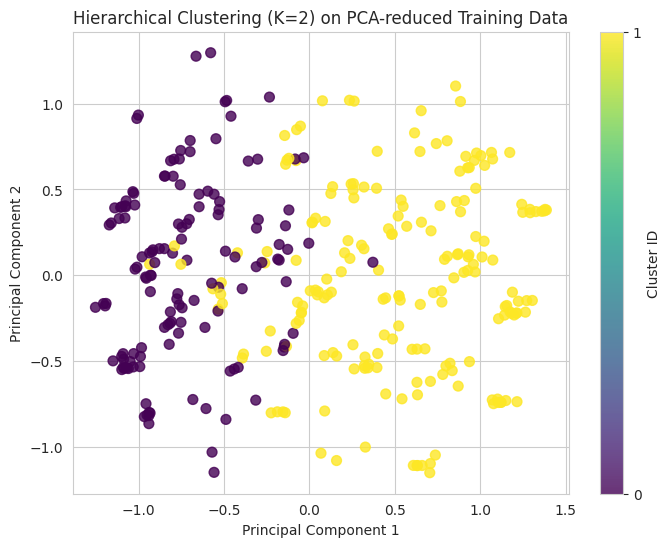

Hierarchical clustering applied and visualized.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

print("\n--- Hierarchical Clustering ---")

# Perform hierarchical clustering
linked = linkage(X_unsupervised_train, method='ward') # 'ward' minimizes the variance of the clusters being merged

# Plotting the dendrogram (may be very dense for large datasets, consider truncating)
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    labels=clusters_kmeans if 'clusters_kmeans' in globals() else None, # Using K-Means labels for comparison if available
    distance_sort='descending',
    show_leaf_counts=True,
    truncate_mode='lastp', # Show only the last 'p' merged clusters
    p=optimal_k_kmeans if 'optimal_k_kmeans' in globals() else 10 # Truncate to show 'optimal_k_kmeans' or 10 clusters
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.savefig(os.path.join(PLOT_DIR, 'hierarchical_dendrogram.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Apply AgglomerativeClustering with the same number of clusters as K-Means for comparison
# Ensure optimal_k_kmeans is defined, otherwise default to a reasonable number like 3
clusters_to_use = optimal_k_kmeans if 'optimal_k_kmeans' in globals() else 3
hierarchical_optimal = AgglomerativeClustering(n_clusters=clusters_to_use, linkage='ward') # Removed affinity parameter
clusters_hierarchical = hierarchical_optimal.fit_predict(X_unsupervised_train)

# Visualize Hierarchical clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_hierarchical, cmap='viridis', s=50, alpha=0.8)
plt.title(f'Hierarchical Clustering (K={clusters_to_use}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(clusters_to_use), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'hierarchical_clusters_k{clusters_to_use}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("Hierarchical clustering applied and visualized.")


--- Hierarchical Clustering ---


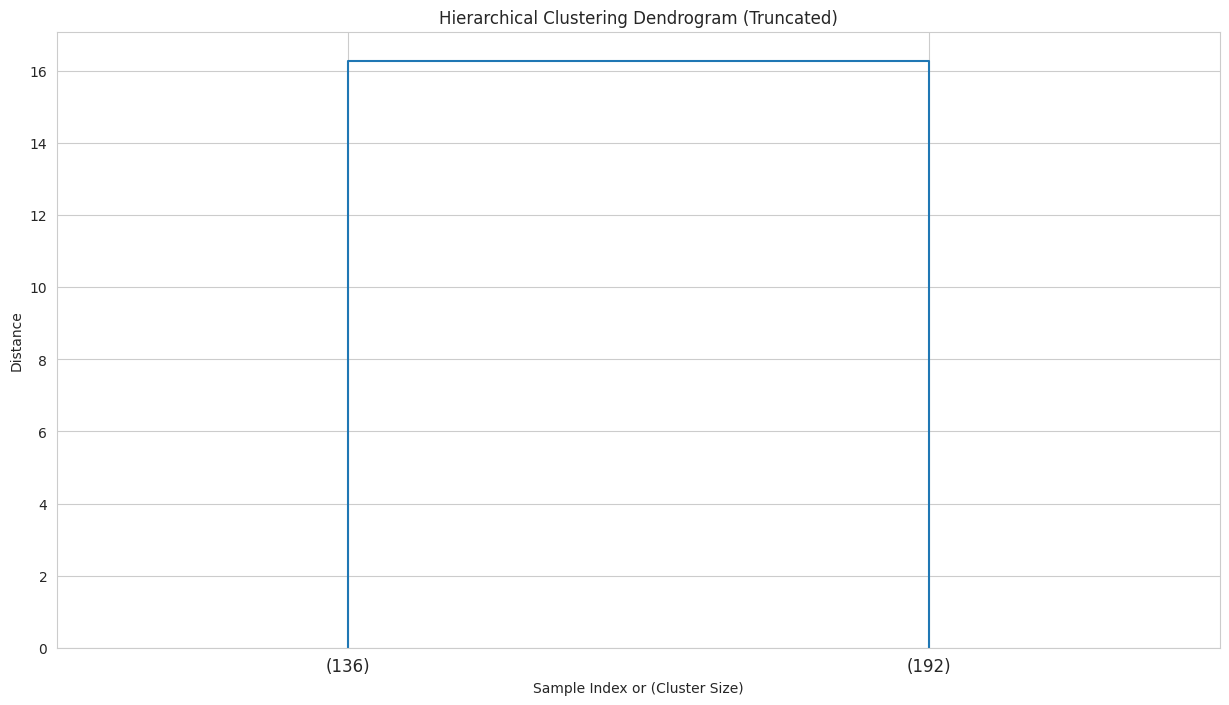

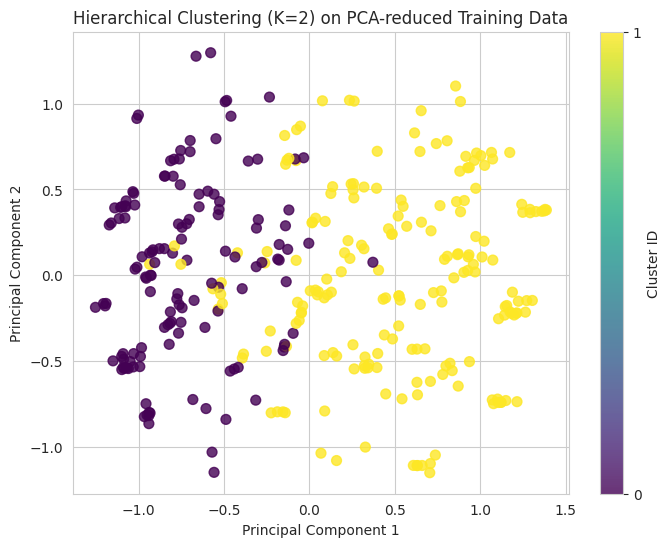

Hierarchical clustering applied and visualized.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

print("\n--- Hierarchical Clustering ---")

# Perform hierarchical clustering
linked = linkage(X_unsupervised_train, method='ward') # 'ward' minimizes the variance of the clusters being merged

# Plotting the dendrogram (may be very dense for large datasets, consider truncating)
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    labels=clusters_kmeans if 'clusters_kmeans' in globals() else None, # Using K-Means labels for comparison if available
    distance_sort='descending',
    show_leaf_counts=True,
    truncate_mode='lastp', # Show only the last 'p' merged clusters
    p=optimal_k_kmeans if 'optimal_k_kmeans' in globals() else 10 # Truncate to show 'optimal_k_kmeans' or 10 clusters
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.savefig(os.path.join(PLOT_DIR, 'hierarchical_dendrogram.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Apply AgglomerativeClustering with the same number of clusters as K-Means for comparison
# Ensure optimal_k_kmeans is defined, otherwise default to a reasonable number like 3
clusters_to_use = optimal_k_kmeans if 'optimal_k_kmeans' in globals() else 3
hierarchical_optimal = AgglomerativeClustering(n_clusters=clusters_to_use, linkage='ward') # Removed affinity parameter
clusters_hierarchical = hierarchical_optimal.fit_predict(X_unsupervised_train)

# Visualize Hierarchical clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_hierarchical, cmap='viridis', s=50, alpha=0.8)
plt.title(f'Hierarchical Clustering (K={clusters_to_use}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(clusters_to_use), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'hierarchical_clusters_k{clusters_to_use}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("Hierarchical clustering applied and visualized.")

In [ ]:
from sklearn.mixture import GaussianMixture

print("\n--- Gaussian Mixture Model (GMM) ---")

# Determine optimal number of components using BIC/AIC
n_components_range = range(2, max_k + 1)
bic = []
aic = []

for n_comp in n_components_range:
    gmm = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    gmm.fit(X_unsupervised_train)
    bic.append(gmm.bic(X_unsupervised_train))
    aic.append(gmm.aic(X_unsupervised_train))

print("BIC and AIC scores calculated for GMM.")


--- Gaussian Mixture Model (GMM) ---
BIC and AIC scores calculated for GMM.


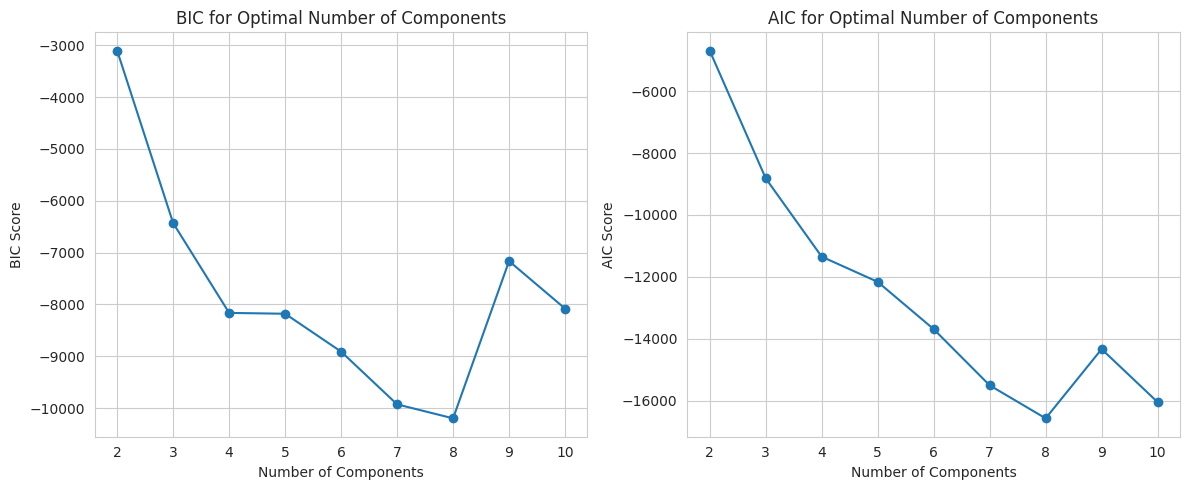

Optimal number of components for GMM (based on BIC): 8


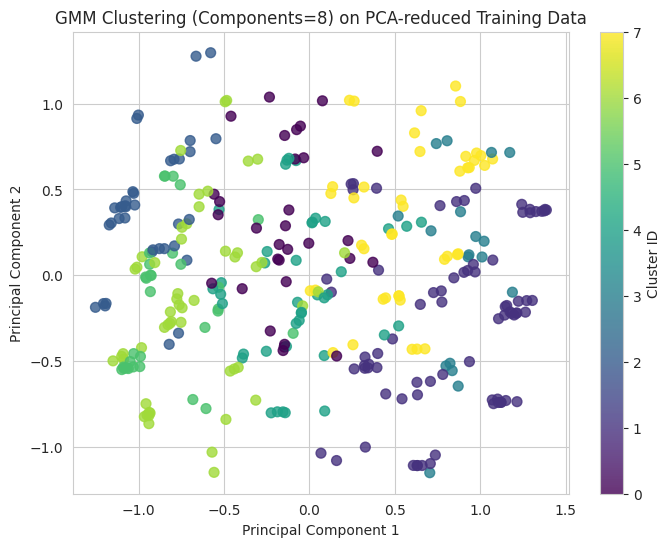

GMM clustering with optimal components applied and visualized.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_components_range, bic, marker='o')
plt.title('BIC for Optimal Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_components_range, aic, marker='o')
plt.title('AIC for Optimal Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('AIC Score')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'gmm_optimal_components.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

# Determine optimal components (choose component with lowest BIC)
optimal_components_gmm = n_components_range[np.argmin(bic)]
print(f"Optimal number of components for GMM (based on BIC): {optimal_components_gmm}")

# Apply GMM with optimal components
gmm_optimal = GaussianMixture(n_components=optimal_components_gmm, random_state=42, n_init=10)
gmm_optimal.fit(X_unsupervised_train)
clusters_gmm = gmm_optimal.predict(X_unsupervised_train)

# Visualize GMM clusters (using PCA for 2D plot)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_gmm, cmap='viridis', s=50, alpha=0.8)
plt.title(f'GMM Clustering (Components={optimal_components_gmm}) on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, ticks=range(optimal_components_gmm), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'gmm_clusters_comp{optimal_components_gmm}.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("GMM clustering with optimal components applied and visualized.")

Visualizing GMM clusters with 8 components and covariance ellipses...


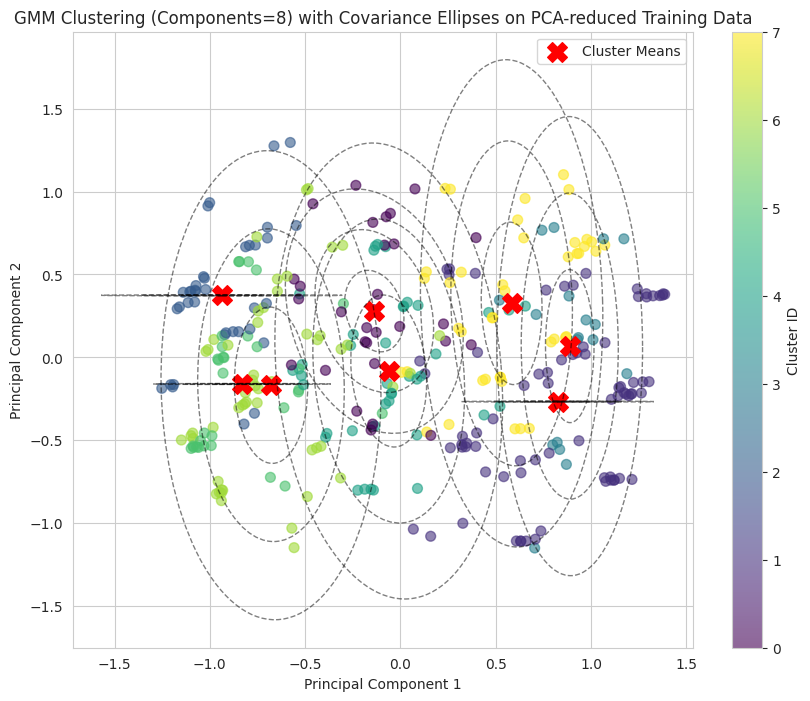

GMM clustering with covariance ellipses visualized and saved.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
import os

# Function to draw covariance ellipses (corrected version)
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        # As we're plotting on PCA-reduced 2D data, covariance should be 2x2
        # If it's not, handle it (e.g., take the first two components)
        U, s, Vt = np.linalg.svd(covariance[:2, :2]) # Consider only 2D part
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)

    # Draw the ellipse with explicit keyword arguments for xy, width, height, and angle
    for nstd in range(1, 4):
        ax.add_patch(Ellipse(xy=position, width=nstd * width, height=nstd * height, angle=angle,
                             fill=False, linestyle='--', color='black', alpha=0.5, **kwargs))

print(f"Visualizing GMM clusters with {optimal_components_gmm} components and covariance ellipses...")

# Visualize GMM clusters with covariance ellipses
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_gmm, cmap='viridis', s=50, alpha=0.6)
plt.title(f'GMM Clustering (Components={optimal_components_gmm}) with Covariance Ellipses on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot cluster means (transformed by PCA)
cluster_means_pca = pca.transform(gmm_optimal.means_)
plt.scatter(cluster_means_pca[:, 0], cluster_means_pca[:, 1],
            marker='X', s=200, color='red', label='Cluster Means')

# Draw ellipses for each cluster using the corrected draw_ellipse function
for i in range(optimal_components_gmm):
    draw_ellipse(cluster_means_pca[i], gmm_optimal.covariances_[i], ax=plt.gca())

plt.legend()
plt.colorbar(scatter, ticks=range(optimal_components_gmm), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'gmm_clusters_comp{optimal_components_gmm}_ellipses.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("GMM clustering with covariance ellipses visualized and saved.")

Visualizing GMM clusters with 8 components and covariance ellipses...


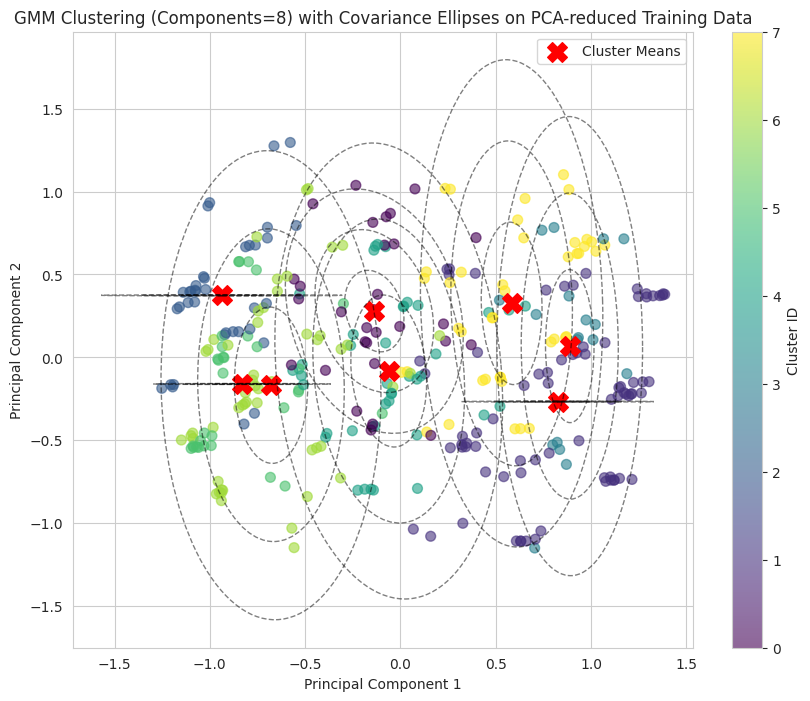

GMM clustering with covariance ellipses visualized and saved.


In [ ]:
# Function to draw covariance ellipses (corrected version)
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        # As we're plotting on PCA-reduced 2D data, covariance should be 2x2
        # If it's not, handle it (e.g., take the first two components)
        U, s, Vt = np.linalg.svd(covariance[:2, :2]) # Consider only 2D part
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)

    # Draw the ellipse with explicit keyword arguments for xy, width, height, and angle
    for nstd in range(1, 4):
        ax.add_patch(Ellipse(xy=position, width=nstd * width, height=nstd * height, angle=angle,
                             fill=False, linestyle='--', color='black', alpha=0.5, **kwargs))

print(f"Visualizing GMM clusters with {optimal_components_gmm} components and covariance ellipses...")

# Visualize GMM clusters with covariance ellipses
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_gmm, cmap='viridis', s=50, alpha=0.6)
plt.title(f'GMM Clustering (Components={optimal_components_gmm}) with Covariance Ellipses on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot cluster means (transformed by PCA)
cluster_means_pca = pca.transform(gmm_optimal.means_)
plt.scatter(cluster_means_pca[:, 0], cluster_means_pca[:, 1],
            marker='X', s=200, color='red', label='Cluster Means')

# Draw ellipses for each cluster using the corrected draw_ellipse function
for i in range(optimal_components_gmm):
    draw_ellipse(cluster_means_pca[i], gmm_optimal.covariances_[i], ax=plt.gca())

plt.legend()
plt.colorbar(scatter, ticks=range(optimal_components_gmm), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'gmm_clusters_comp{optimal_components_gmm}_ellipses.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("GMM clustering with covariance ellipses visualized and saved.")

Visualizing GMM clusters with 8 components and covariance ellipses...


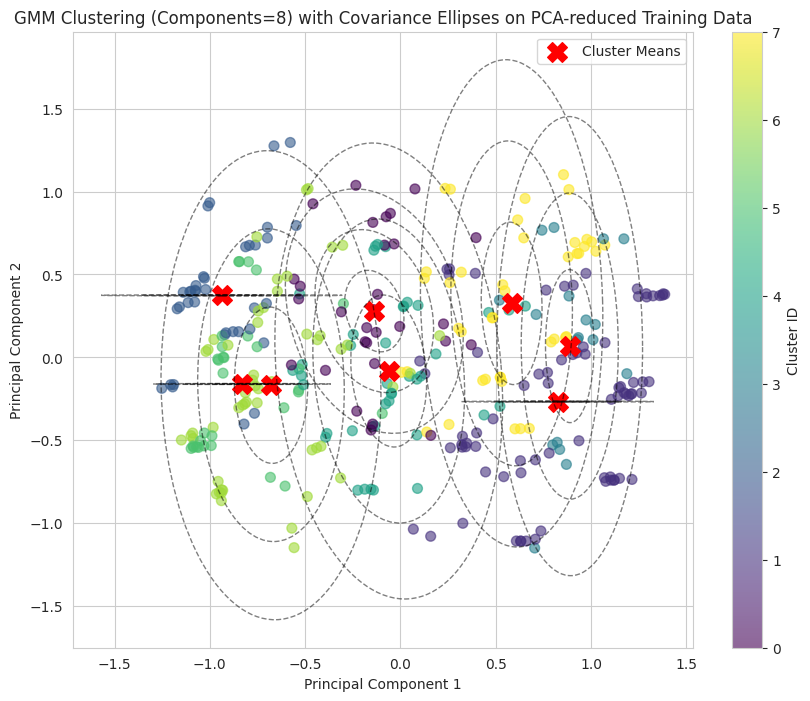

GMM clustering with covariance ellipses visualized and saved.


In [ ]:
# Function to draw covariance ellipses
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        # As we're plotting on PCA-reduced 2D data, covariance should be 2x2
        # If it's not, handle it (e.g., take the first two components)
        U, s, Vt = np.linalg.svd(covariance[:2, :2]) # Consider only 2D part
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)

    # Draw the ellipse
    for nstd in range(1, 4):
        ax.add_patch(Ellipse(xy=position, width=nstd * width, height=nstd * height, angle=angle,
                             fill=False, linestyle='--', color='black', alpha=0.5, **kwargs))

print(f"Visualizing GMM clusters with {optimal_components_gmm} components and covariance ellipses...")

# Visualize GMM clusters with covariance ellipses
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_gmm, cmap='viridis', s=50, alpha=0.6)
plt.title(f'GMM Clustering (Components={optimal_components_gmm}) with Covariance Ellipses on PCA-reduced Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot cluster means (transformed by PCA)
cluster_means_pca = pca.transform(gmm_optimal.means_)
plt.scatter(cluster_means_pca[:, 0], cluster_means_pca[:, 1],
            marker='X', s=200, color='red', label='Cluster Means')

# Draw ellipses for each cluster
for i in range(optimal_components_gmm):
    draw_ellipse(cluster_means_pca[i], gmm_optimal.covariances_[i], ax=plt.gca())

plt.legend()
plt.colorbar(scatter, ticks=range(optimal_components_gmm), label='Cluster ID')
plt.grid(True)
plt.savefig(os.path.join(PLOT_DIR, f'gmm_clusters_comp{optimal_components_gmm}_ellipses.png'))
if DISPLAY_PLOTS:
    plt.show()
plt.close()

print("GMM clustering with covariance ellipses visualized and saved.")


In [ ]:
for name, df_enc in df_tests_encoded.items():
    print(f"\n{name} chol value counts (top 10):")
    print(df_enc["chol"].value_counts().head(10))



Hungarian chol value counts (top 10):
chol
250.848708    23
275.000000     5
230.000000     5
246.000000     5
260.000000     4
216.000000     4
224.000000     4
211.000000     4
263.000000     4
237.000000     4
Name: count, dtype: int64

Switzerland chol value counts (top 10):
Series([], Name: count, dtype: int64)

VA chol value counts (top 10):
chol
178.746114    7
203.000000    4
220.000000    4
258.000000    4
214.000000    3
240.000000    3
236.000000    3
216.000000    3
223.000000    3
186.000000    3
Name: count, dtype: int64
